# Geospatial Data Analysis Lab: Steel Plants Dataset


**Learning Objectives:**
- Perform exploratory data analysis (EDA) on geospatial datasets
- Visualize geospatial data using interactive maps with Plotly
- Merge granular exposure / population data (LitPop) with asset locations
- Aggregate data at the company level
- Integrate geospatial visualizations into a Streamlit dashboard

**Dataset:** Download the Global Energy Monitor [Global Iron and Steel Tracker](https://globalenergymonitor.org/projects/global-iron-steel-tracker) (formerly Global Steel Plant Tracker). Use the plant-level download from that page and place the file in the same folder as this notebook (or update the load path accordingly).

---


## Submission info

| # | Full name | Student ID |
|---|-----------|------------|
| 1 | Adam Zeraiki | B00819260 |
| 2 | Lina Oumhand | B00820945 |
| 3 | Chris William Karam | B00825083 |
| 4 | Liam Szefner | B00822121 |

**Group / repo name:** `aidams-lab1-Zeraiki-Oumhand-Karam-Szefner`  
**Submitter:** Adam Zeraiki  
**Repo URL:** [https://github.com/Azzbee/aidams-lab1-Zeraiki-Oumhand-Karam-Szefner](https://github.com/Azzbee/aidams-lab1-Zeraiki-Oumhand-Karam-Szefner)  
**Streamlit Cloud URL (bonus):** [https://aidams-lab1-zeraiki-oumhand-karam-szefner.streamlit.app/](https://aidams-lab1-zeraiki-oumhand-karam-szefner.streamlit.app/)


## How this notebook is organised

**Data.** Global Energy Monitor's *Global Iron and Steel Tracker*, June 2026 (V1), and the Moodle LitPop sample for China, India and Japan. The workbook sits beside the notebook; LitPop files may be in `litpop/` or `data/`.

**Method.** Column names are harmonised to the handout. Capacity is aggregated by plant and status: operating capacity is kept separate from planned, idle and closed capacity. `N/A` means not applicable; `unknown` and `>0` retain missing magnitudes. Coordinates are checked before mapping, and one longitude correction is logged. Operating routes use equipment from operating status rows.

**Exposure.** Plants in the three sample countries receive their nearest LitPop cell within 13.1 km, plus the sum of cells within 25 km. These are surrounding asset values, not estimates of plant value or climate losses.

**Figures.** Each Plotly figure is saved as an interactive output and a PNG for viewers that do not run JavaScript. PNG export requires Kaleido and Chrome.

## Part 1: Setup and Data Loading

Import the necessary libraries and load the steel plants dataset.

**Tip:** After loading, run `df.columns` and `df.head()`. Column names in the file may differ slightly by release: inspect them and adapt your code accordingly.


In [1]:
import json
import re
import time
from pathlib import Path

import h5py  # the LitPop sample files are HDF5
import numpy as np
import pandas as pd
import plotly
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from IPython.display import display
from numpy.typing import ArrayLike, NDArray
from sklearn.neighbors import (
    BallTree,  # nearest-neighbour search with great-circle (haversine) distances
)

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 70)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", "{:,.2f}".format)

# Raw files sit next to this notebook (as the lab asks); processed exports for the dashboard go to ./data
RAW_DIR = Path(".")
LITPOP_DIR = RAW_DIR / "litpop"
if not any(LITPOP_DIR.glob("LitPop_*.hdf5")):
    LITPOP_DIR = RAW_DIR / "data"
EXPORT_DIR = RAW_DIR / "data"

EARTH_RADIUS_KM = 6371.0088  # mean Earth radius, converts radians <-> kilometres

print(f"pandas {pd.__version__} | numpy {np.__version__} | plotly {plotly.__version__}")

pandas 3.0.5 | numpy 2.5.3 | plotly 7.1.0


In [2]:
# Plotly configuration: keep every figure visible in the saved notebook, on any Plotly version
def configure_plotly() -> str:
    """Choose a renderer that keeps every figure visible in the saved notebook.

    - `plotly_mimetype` stores the interactive figure (rendered by VS Code, JupyterLab and Notebook 7).
    - `png` stores a static copy of the same figure. GitHub's notebook viewer does not run JavaScript,
      so without this copy the maps would look empty there.
    PNG export needs the optional `kaleido` package plus Chrome. If they are missing we keep Plotly's
    default interactive renderer, so the notebook still runs.
    """
    pio.templates.default = "plotly_white"
    pio.renderers.default = "plotly_mimetype"
    try:
        px.scatter(x=[0], y=[0]).to_image(format="png", width=40, height=40)  # smoke test of the PNG export
    except Exception as error:  # any failure simply means "no static export on this machine"
        print(f"Static PNG export unavailable ({type(error).__name__}): interactive output only.")
        return str(pio.renderers.default)
    png_renderer = pio.renderers["png"]
    png_renderer.width, png_renderer.scale = 1000, 1.0
    pio.renderers.default = "plotly_mimetype+png"
    return str(pio.renderers.default)


REGION_COLOURS = {  # one colour per GEM region, reused by every chart and by the dashboard (colour-blind-safe palette)
    "Asia Pacific": "#88CCEE",
    "Europe": "#CC6677",
    "North America": "#DDCC77",
    "Middle East": "#117733",
    "Africa": "#332288",
    "Eurasia": "#AA4499",
    "Central & South America": "#44AA99",
}

# The declared Plotly minimum (5.24) supports the current map functions.
density_map_fn = px.density_map

print("Plotly renderer      :", configure_plotly())
print("Density map function :", density_map_fn.__name__)

Plotly renderer      : plotly_mimetype+png
Density map function : density_map


In [3]:
# Load the GEM workbook and harmonise column names.

GEM_FILE_PATTERNS = ("*Iron*Steel*Tracker*.xlsx", "*Steel*Plant*Tracker*.xlsx")
CAPACITY_COL = "Nominal crude steel capacity (ttpa)"
IRON_CAPACITY_COL = "Nominal iron capacity (ttpa)"

# GEM renames columns between releases (the "About" sheet of the 2026 file lists the changes). We map every known
# variant to the names used in the lab handout, so the rest of the notebook is written once, against one vocabulary.
COLUMN_ALIASES = {
    "Plant ID": ["GEM plant ID"],
    "Country/Area": ["Country/area", "Country"],
    "Plant age (years)": ["Plant age"],
    "Parent": ["Parent (English)"],
    "Subnational unit (province/state)": ["Subnational unit"],
    "SOE Status": ["SOE status"],
}


def _normalise(name: object) -> str:
    """Lower-case a column name and collapse whitespace, so 'Country/area' and 'Country/Area ' compare equal."""
    return " ".join(str(name).lower().split())


def harmonise_columns(table: pd.DataFrame) -> tuple[pd.DataFrame, dict[str, str]]:
    """Rename release-specific column names to the canonical names of the lab handout. Returns (table, renames)."""
    lookup = {
        _normalise(alias): canonical for canonical, aliases in COLUMN_ALIASES.items() for alias in [canonical, *aliases]
    }
    renames = {
        col: lookup[_normalise(col)]
        for col in table.columns
        if _normalise(col) in lookup and col != lookup[_normalise(col)]
    }
    return table.rename(columns=renames), renames


def find_gem_file(folder: Path) -> Path:
    """Return the GEM plant-level workbook stored in `folder` (the most recent one if there are several)."""
    candidates = {path for pattern in GEM_FILE_PATTERNS for path in folder.glob(pattern)}
    # The unit-level downloads ("Iron unit data", "Steel unit data") are separate files: keep the plant-level one.
    plant_level = [p for p in candidates if "unit" not in p.name.lower() and not p.name.startswith("~$")]
    if not plant_level:
        raise FileNotFoundError(
            f"No Global Iron and Steel Tracker workbook found in '{folder.resolve()}'. Download the plant-level "
            "file from https://globalenergymonitor.org/projects/global-iron-steel-tracker and put it next to this notebook."
        )
    return max(plant_level, key=lambda p: p.stat().st_mtime)


def load_gem_workbook(path: Path) -> dict[str, pd.DataFrame]:
    """Read every sheet of the workbook.

    `keep_default_na=False` matters: by default pandas converts the text "N/A" into NaN, which would erase
    GEM's distinction between "N/A" (not applicable) and "unknown" (genuinely missing).
    """
    return pd.read_excel(path, sheet_name=None, keep_default_na=False, na_values=[""])


def pick_sheet(sheets: dict[str, pd.DataFrame], required_columns: list[str]) -> str:
    """Return the name of the first sheet containing all `required_columns` (sheet names change across releases)."""
    for name, table in sheets.items():
        if set(required_columns).issubset(table.columns):
            return name
    raise KeyError(f"No sheet contains {required_columns}. Sheets found: {list(sheets)}")


def read_release_label(sheets: dict[str, pd.DataFrame], path: Path) -> str:
    """Read the release name from the 'About' sheet, falling back to the file name."""
    about = sheets.get("About")
    if about is not None:
        cells = [str(c) for c in about.columns] + [str(v) for v in about.to_numpy().ravel()]
        for cell in cells:
            match = re.search(r"Tracker,\s*([A-Z][a-z]+ \d{4}(?: \(V[\d.]+\))?)", cell)
            if match:
                return match.group(1)
    return path.stem


gem_path = find_gem_file(RAW_DIR)
sheets = load_gem_workbook(gem_path)
GEM_RELEASE = read_release_label(sheets, gem_path)

column_renames = {}
for sheet_name in list(sheets):
    sheets[sheet_name], renamed = harmonise_columns(sheets[sheet_name])
    column_renames.update(renamed)

plant_sheet = pick_sheet(sheets, ["Plant ID", "Plant name (English)", "Owner", "Coordinates"])
capacity_sheet = pick_sheet(sheets, ["Plant ID", "Status", CAPACITY_COL])

df = sheets[plant_sheet].copy()  # one row per plant
capacity_raw = sheets[capacity_sheet].copy()  # one row per plant AND capacity status

print(f"File       : {gem_path.name}")
print(f"Release    : {GEM_RELEASE}")
print(f"Sheets     : {list(sheets)}")
print(f"Renamed    : {column_renames if column_renames else 'nothing, the file already uses the handout names'}")
print(f"Plant data : sheet '{plant_sheet}' -> {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Capacities : sheet '{capacity_sheet}' -> {capacity_raw.shape[0]:,} rows x {capacity_raw.shape[1]} columns")
print("\nColumns of the plant sheet:\n", df.columns.tolist())
print("\nColumns of the capacity sheet:\n", capacity_raw.columns.tolist())
display(df.head(3))
display(capacity_raw.head(5))

File       : Plant-level_data_Global_Iron_and_Steel_Tracker_June_2026_V1.xlsx
Release    : June 2026 (V1)
Sheets     : ['About', 'Metadata', 'Plant data', 'Plant capacities and status', 'Plant production']
Renamed    : {'GEM plant ID': 'Plant ID', 'SOE status': 'SOE Status', 'Parent (English)': 'Parent', 'Subnational unit': 'Subnational unit (province/state)', 'Country/area': 'Country/Area', 'Plant age': 'Plant age (years)'}
Plant data : sheet 'Plant data' -> 1,293 rows x 44 columns
Capacities : sheet 'Plant capacities and status' -> 1,845 rows x 16 columns

Columns of the plant sheet:
 ['Plant ID', 'Plant name (English)', 'Plant name (other language)', 'Other plant names (English)', 'Other plant names (other language)', 'Owner', 'Owner (other language)', 'Owner GEM entity ID', 'Owner PermID', 'SOE Status', 'Parent', 'Parent GEM entity ID', 'Parent PermID', 'Location address', 'Location address (other language)', 'Municipality', 'Subnational unit (province/state)', 'Country/Area', 'Reg

,Plant ID,Plant name (English),Plant name (other language),Other plant names (English),Other plant names (other language),Owner,Owner (other language),Owner GEM entity ID,Owner PermID,SOE Status,Parent,Parent GEM entity ID,Parent PermID,Location address,Location address (other language),Municipality,Subnational unit (province/state),Country/Area,Region,Coordinates,Coordinate accuracy,GEM wiki page,Plant age (years),Announced date,Construction date,Start date,Pre-retirement announcement date,Idled date,Retired date,Ferronickel capacity (ttpa),Sinter plant capacity (ttpa),Coking plant capacity (ttpa),Pelletizing plant capacity (ttpa),Category steel product,Steel products,Steel sector end users,Workforce size,ISO 14001,ISO 50001,ResponsibleSteel certification,Main production equipment,Power source,Iron ore source,Met coal source
0,P100000120882,Aba Iron and Steel Payas plant,ABA DEMİR ÇELİK,"EEY Iron and Steel, Nursan Steel Payas Plant (predecessor), Nursan...",NaN,ABA Çelik Demir LŞ,ABA Demir ve Çelik İthalat İhracat Ticaret,E100000131190,unknown,N/A,ABA Çelik Demir LŞ [100.0%],E100000131190 [100.0%],unknown [100.0%],"3 Sanayi Bolgesi Sincan, Payas, Hatay, 31900 Türkiye",NaN,Payas,Hatay,Türkiye,Europe,"36.7474130, 36.2173300",exact,https://www.gem.wiki/Aba_Iron_and_Steel_Payas_plant,43,unknown,unknown,1983,unknown,unknown,unknown,N/A,N/A,N/A,N/A,"crude, semi-finished, finished rolled","billet, wire rod, angle, flat, bar, square bar, round bar, pfc, t ...",unknown,900,unknown,unknown,no,EAF,unknown,unknown,N/A
1,P100000120753,Abba Steel Ohangwena steel plant,NaN,Groot Suisse Oshana plant,NaN,Abba Steel Ltd,NaN,E100001012072,unknown,N/A,Abba Steel Ltd [100.0%],E100001012072 [100.0%],unknown [100.0%],"Eeshoke Village, Oshikango, Ohangwena Region, Namibia",NaN,Oshikango,Ohangwena,Namibia,Africa,"-17.3978660, 15.8910220",approximate,https://www.gem.wiki/Abba_Steel_Ohangwena_steel_plant,1,2019,2020,2025,unknown,unknown,unknown,N/A,unknown,N/A,unknown,"semi-finished, finished rolled","billet, wire rod, rebar",building and infrastructure,5500,unknown,unknown,no,EAF,unknown,unknown,N/A
2,P100000120802,Abinsk Electric Steel Works,АЭМЗ,"AESW, ASW, AEMZ, AEMK",Абинский ЭлектроМеталлургический завод,Abinski Elektrometallurgicheski Zavod LLC,"ООО ""АБИНСКИЙ ЭЛЕКТРОМЕТАЛЛУРГИЧЕСКИЙ ЗАВОД""",E100000130999,5039667129,N/A,Novostal-M LLC [100.0%],E100000131027 [100.0%],5046391773 [100.0%],"Promyshlennaya, 4, Abinsk, Krasnodarskiy Kray, 353320, Russia","353320, Российская Федерация, Краснодарский Край, г. Абинск, ул. П...",Abinsk,Krasnodar,Russia,Eurasia,"44.8819380, 38.1275100",exact,https://www.gem.wiki/Abinsk_Electric_Steel_Works,12,unknown,2008,2014,unknown,unknown,unknown,N/A,N/A,N/A,N/A,"semi-finished, finished rolled","wire rod, rebar, bar, billet, round bar, wire",unknown,4500,2025-10-06 00:00:00,unknown,no,EAF,unknown,N/A,unknown


,Plant ID,Plant name (English),Plant name (other language),Country/Area,Main production equipment,Status,Start date,Nominal crude steel capacity (ttpa),Nominal BOF steel capacity (ttpa),Nominal EAF steel capacity (ttpa),Nominal IF steel capacity (ttpa),Other/unspecified steel capacity (ttpa),Nominal iron capacity (ttpa),Nominal BF capacity (ttpa),Nominal DRI capacity (ttpa),Other/unspecified iron capacity (ttpa)
0,P100000120882,Aba Iron and Steel Payas plant,ABA DEMİR ÇELİK,Türkiye,EAF,operating,1983,1100,N/A,1100,N/A,N/A,N/A,N/A,N/A,N/A
1,P100000120753,Abba Steel Ohangwena steel plant,NaN,Namibia,EAF,construction,unknown,3000,N/A,3000,N/A,N/A,N/A,N/A,N/A,N/A
2,P100000120802,Abinsk Electric Steel Works,АЭМЗ,Russia,EAF,operating,2014,1600,N/A,1600,N/A,N/A,N/A,N/A,N/A,N/A
3,P100000120020,Abul Khair Steel Sitakunda plant,আবুল খায়ের স্টিল মেল্টিং লিমিটেড,Bangladesh,EAF,operating,2015,1400,N/A,1400,N/A,N/A,N/A,N/A,N/A,N/A
4,P100000120284,Tianjin New Tiangang United Special Steel Co Ltd,天津天钢联合特钢有限公司，天津天钢联合钢铁有限公司,China,BF,retired,2009-06-24 00:00:00,N/A,N/A,N/A,N/A,N/A,2360,2360,N/A,N/A


**What the workbook contains.** Five sheets: `About` (release and licence), `Metadata` (column definitions), `Plant data` (one row per plant, 44 columns), `Plant capacities and status` (capacity per plant **and** status) and `Plant production`. The capacity column named in the handout, `Nominal crude steel capacity (ttpa)`, is **not** on the plant sheet: it has to be aggregated from the capacity sheet and merged back, which is done in the data preparation step below.

`df` is the raw plant sheet, as the handout suggests. The cleaned table used from Question 2 onwards is called `steel_plants` (descriptive name instead of `df`).

---
## Part 2: Exploratory Data Analysis

Answer the following questions through your analysis:


### Question 1: Data Overview
**Task:** Display basic information about the dataset.
- How many steel plants are in the dataset?
- What are the column names and data types? (use `df.columns` / `df.dtypes` or `df.info()`, then adapt later code to the names you see)
- Are there any missing values?


In [4]:
# Display dataset shape

n_plants, n_columns = df.shape
print(f"Plant sheet    : {n_plants:,} rows x {n_columns} columns")
print(f"Unique plants  : {df['Plant ID'].nunique():,} Plant IDs, {df['Plant ID'].duplicated().sum()} duplicated")
print(f"Capacity sheet : {len(capacity_raw):,} rows for {capacity_raw['Plant ID'].nunique():,} plants")
print(f"Plants missing from one of the two sheets: {len(set(df['Plant ID']) ^ set(capacity_raw['Plant ID']))}")

rows_per_plant = capacity_raw.groupby("Plant ID").size().value_counts().sort_index()
display(rows_per_plant.rename_axis("capacity rows per plant").to_frame("number of plants"))

Plant sheet    : 1,293 rows x 44 columns
Unique plants  : 1,293 Plant IDs, 0 duplicated
Capacity sheet : 1,845 rows for 1,293 plants
Plants missing from one of the two sheets: 0


,number of plants
capacity rows per plant,
1,903
2,277
3,70
4,37
5,6


In [5]:
# Display column information and data types
# Start here: print(df.columns) and adapt column names in later cells if needed

print(df.columns.tolist(), "\n")
df.info()
print("\nCapacity sheet dtypes:")
print(capacity_raw.dtypes)

['Plant ID', 'Plant name (English)', 'Plant name (other language)', 'Other plant names (English)', 'Other plant names (other language)', 'Owner', 'Owner (other language)', 'Owner GEM entity ID', 'Owner PermID', 'SOE Status', 'Parent', 'Parent GEM entity ID', 'Parent PermID', 'Location address', 'Location address (other language)', 'Municipality', 'Subnational unit (province/state)', 'Country/Area', 'Region', 'Coordinates', 'Coordinate accuracy', 'GEM wiki page', 'Plant age (years)', 'Announced date', 'Construction date', 'Start date', 'Pre-retirement announcement date', 'Idled date', 'Retired date', 'Ferronickel capacity (ttpa)', 'Sinter plant capacity (ttpa)', 'Coking plant capacity (ttpa)', 'Pelletizing plant capacity (ttpa)', 'Category steel product', 'Steel products', 'Steel sector end users', 'Workforce size', 'ISO 14001', 'ISO 50001', 'ResponsibleSteel certification', 'Main production equipment', 'Power source', 'Iron ore source', 'Met coal source'] 

<class 'pandas.DataFrame'>
R

In [6]:
# Check for missing values

MISSING_TOKENS = ("unknown", ">0")  # GEM's text placeholders for "we do not know the value"


def missing_report(table: pd.DataFrame) -> pd.DataFrame:
    """Count real gaps per column: empty cells plus GEM's text placeholders.

    "N/A" is reported separately because it means "not applicable" (for example a plant without a coke oven),
    which is information, not a gap.
    """
    text = table.astype(str).apply(lambda column: column.str.strip().str.lower())
    report = pd.DataFrame(
        {
            "empty cell": table.isna().sum(),
            "'unknown'": (text == "unknown").sum(),
            "'>0'": (text == ">0").sum(),
            "'N/A' (not applicable)": (text == "n/a").sum(),
        }
    )
    gaps = report[["empty cell", "'unknown'", "'>0'"]].sum(axis=1)
    report["missing %"] = (gaps / len(table) * 100).round(1)
    return report.sort_values("missing %", ascending=False)


plant_missing = missing_report(df)
print(f"Naive check, df.isna().sum().sum()         : {int(df.isna().sum().sum()):,} empty cells")
GAP_COLUMNS = ["empty cell", "'unknown'", "'>0'"]
print(
    f"Including the 'unknown' / '>0' placeholders : {int(plant_missing[GAP_COLUMNS].to_numpy().sum()):,} missing values"
)

KEY_COLUMNS = [
    "Plant name (English)",
    "Owner",
    "Parent",
    "Country/Area",
    "Region",
    "Coordinates",
    "Coordinate accuracy",
    "Plant age (years)",
    "Start date",
]
print("\nColumns this lab relies on:")
display(plant_missing.loc[[c for c in KEY_COLUMNS if c in plant_missing.index]])
print("Plant sheet, 15 columns with the most missing values:")
display(plant_missing.head(15))
print("Capacity sheet:")
display(missing_report(capacity_raw).loc[lambda r: r.drop(columns="missing %").sum(axis=1) > 0])

Naive check, df.isna().sum().sum()         : 3,520 empty cells
Including the 'unknown' / '>0' placeholders : 17,874 missing values

Columns this lab relies on:


,empty cell,'unknown','>0','N/A' (not applicable),missing %
Plant name (English),0,0,0,0,0.00
Owner,0,2,0,0,0.20
Parent,0,0,0,0,0.00
Country/Area,0,0,0,0,0.00
Region,0,0,0,0,0.00
Coordinates,0,0,0,0,0.00
Coordinate accuracy,0,0,0,0,0.00
Plant age (years),0,107,0,61,8.30
Start date,0,112,0,0,8.70


Plant sheet, 15 columns with the most missing values:


,empty cell,'unknown','>0','N/A' (not applicable),missing %
Pre-retirement announcement date,0,1257,0,0,97.20
Idled date,0,1245,0,0,96.30
Retired date,0,1185,0,0,91.60
Construction date,0,1121,0,0,86.70
Iron ore source,0,1089,0,16,84.20
Met coal source,0,1085,0,115,83.90
Announced date,0,1028,0,0,79.50
Other plant names (other language),958,0,0,0,74.10
Power source,0,807,0,0,62.40
Location address (other language),794,0,0,0,61.40


Capacity sheet:


,empty cell,'unknown','>0','N/A' (not applicable),missing %
Plant name (other language),700,0,0,0,37.90
Start date,0,284,0,0,15.40
Nominal iron capacity (ttpa),0,0,34,803,1.80
Nominal DRI capacity (ttpa),0,0,18,1547,1.00
Nominal crude steel capacity (ttpa),0,0,16,250,0.90
Other/unspecified iron capacity (ttpa),0,0,13,1806,0.70
Nominal EAF steel capacity (ttpa),0,0,10,906,0.50
Nominal IF steel capacity (ttpa),0,0,6,1749,0.30
Nominal BF capacity (ttpa),0,0,6,1077,0.30
Nominal BOF steel capacity (ttpa),0,0,1,1221,0.10


#### Answer to Question 1

- **How many plants?** **1,293** plants, one row per `Plant ID`, no duplicates, 44 columns. The capacity sheet has 1,845 rows for the same 1,293 plants because capacity is reported per status: 903 plants have a single row, 390 have between 2 and 5 (for example an operating line plus an announced expansion).
- **Column types.** Almost every column is text (`object`/`str`), including fields that should be numeric such as `Plant age (years)`, `Workforce size` and all capacity columns. The reason is that numbers are mixed with text placeholders, so nothing can be summed or averaged before cleaning.
- **Missing values.** `df.isna()` finds 3,520 empty cells, all in optional fields (names and addresses in other languages). That understates the problem: GEM encodes real gaps as the text `unknown` or `>0`. Counting those gives **17,874 missing values**. The fields this lab relies on are well populated: coordinates, country and region are complete, 2 plants have an unknown owner, and `Plant age (years)` is unknown for 107 plants (8.3%) and `N/A` for 61 more (plants not started yet). Development and retirement dates are 80 to 97% unknown, so we do not build on them.
- **`N/A` is not a gap.** It means "not applicable" (a plant without a coke oven has `N/A` coking capacity). For capacity columns we therefore read `N/A` as 0 and `unknown` / `>0` as missing.

### Data preparation (used by every later question)

The questions below need numeric coordinates, numeric ages and one capacity figure per plant, none of which exist in the raw sheets. This step builds the clean table `steel_plants` (one row per plant):

1. **Capacity per plant.** The eight GEM statuses are grouped into four buckets: `operating` (operating, operating pre-retirement), `pipeline` (announced, construction), `idle` (mothballed) and `closed` (retired, cancelled). **"Capacity" in this notebook means the operating bucket**, in thousand tonnes per annum (ttpa). A plant whose only operating figure is `>0` keeps a missing capacity instead of a false zero.
2. **Numeric fields.** `Plant age (years)`, workforce and the auxiliary capacities are converted with one helper (`gem_number`) that applies the placeholder rules above.
3. **Coordinates.** `Coordinates` is split into `Latitude` and `Longitude`, range-checked, then passed through a plausibility check against the other plants of the same country.
4. **Steelmaking route.** Equipment on operating status rows determines the current route (BF-BOF, EAF/IF, DRI-EAF or mixed). Plants without operating rows use their listed equipment. This avoids classifying an operating plant by retired or planned furnaces.

In [7]:
# One capacity figure per plant ------------------------------------------------------------------------------
# GEM reports capacity per plant AND status. We group the eight statuses into four buckets so that capacity that
# is running today is never mixed with capacity that is only planned, idle, or gone.
STATUS_GROUPS = {
    "operating": "operating",
    "operating pre-retirement": "operating",
    "construction": "pipeline",
    "announced": "pipeline",
    "mothballed": "idle",
    "mothballed pre-retirement": "idle",
    "retired": "closed",
    "cancelled": "closed",
}
STATUS_PRIORITY = list(STATUS_GROUPS)  # most "alive" first: gives each plant a single headline status
REQUIRED_PLANT_COLUMNS = [
    "Plant ID",
    "Plant name (English)",
    "Owner",
    "Country/Area",
    "Region",
    "Coordinates",
    "Plant age (years)",
]
OPTIONAL_PLANT_COLUMNS = [
    "Parent",
    "SOE Status",
    "Subnational unit (province/state)",
    "Municipality",
    "Coordinate accuracy",
    "Main production equipment",
    "GEM wiki page",
]
ROUTE_CAPACITY_COLS = {  # operating steel capacity by furnace type, when the release provides it
    "Nominal BOF steel capacity (ttpa)": "capacity_operating_bof_ttpa",
    "Nominal EAF steel capacity (ttpa)": "capacity_operating_eaf_ttpa",
}
AUXILIARY_CAPACITY_COLS = {
    "Sinter plant capacity (ttpa)": "sinter_ttpa",
    "Coking plant capacity (ttpa)": "coking_ttpa",
    "Pelletizing plant capacity (ttpa)": "pelletizing_ttpa",
    "Ferronickel capacity (ttpa)": "ferronickel_ttpa",
}


def gem_number(series: pd.Series, not_applicable_as_zero: bool = False) -> pd.Series:
    """Convert a GEM column to floats.

    "unknown" and ">0" carry no usable magnitude and become NaN. "N/A" means the plant has none of that
    capacity, so for capacity columns it can be read as 0 (`not_applicable_as_zero=True`).
    """
    text = series.astype(str).str.strip()
    numbers = pd.to_numeric(text, errors="coerce")
    if not_applicable_as_zero:
        numbers = numbers.mask(text.str.upper() == "N/A", 0.0)
    return numbers


def parse_coordinates(coordinates: pd.Series) -> pd.DataFrame:
    """Split GEM's "lat, lon" text into numeric Latitude / Longitude columns and validate their ranges."""
    parts = coordinates.astype(str).str.split(",", n=1, expand=True)
    parsed = pd.DataFrame(
        {
            "Latitude": pd.to_numeric(parts[0].str.strip(), errors="coerce"),
            "Longitude": pd.to_numeric(parts[1].str.strip(), errors="coerce"),
        },
        index=coordinates.index,
    )
    out_of_range = (parsed["Latitude"].abs() > 90) | (parsed["Longitude"].abs() > 180)
    if out_of_range.any():
        raise ValueError(f"{int(out_of_range.sum())} coordinate pairs fall outside valid latitude/longitude ranges")
    return parsed


def haversine_km(lat1: ArrayLike, lon1: ArrayLike, lat2: ArrayLike, lon2: ArrayLike) -> NDArray[np.float64]:
    """Great-circle distance in km between points given in degrees (vectorised)."""
    lat1, lon1, lat2, lon2 = (np.deg2rad(np.asarray(a, dtype=float)) for a in (lat1, lon1, lat2, lon2))
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 2 * EARTH_RADIUS_KM * np.arcsin(np.sqrt(np.clip(a, 0.0, 1.0)))


def correct_longitude_sign_errors(
    plants: pd.DataFrame, min_plants: int = 5, far_km: float = 5000.0, near_km: float = 3000.0
) -> pd.DataFrame:
    """Plausibility check on the coordinates, run before anything is mapped or spatially joined.

    Each plant is compared with the median location of the plants of its own country (countries with at least
    `min_plants` plants). A plant lying more than `far_km` away that falls back within `near_km` once the sign of
    its longitude is flipped has its east/west sign mistyped: the longitude is corrected in place.
    Returns the corrected rows so the change is logged, never silent.
    """
    by_country = plants.groupby("Country/Area")
    median = by_country[["Latitude", "Longitude"]].transform("median")
    distance = haversine_km(plants["Latitude"], plants["Longitude"], median["Latitude"], median["Longitude"])
    mirrored = haversine_km(plants["Latitude"], -plants["Longitude"], median["Latitude"], median["Longitude"])
    wrong_sign = (by_country["Plant ID"].transform("size") >= min_plants) & (distance > far_km) & (mirrored < near_km)
    log = plants.loc[wrong_sign, ["Plant ID", "Plant name (English)", "Country/Area", "Coordinates"]].assign(
        km_from_country_median=distance[wrong_sign].round(0), km_after_sign_flip=mirrored[wrong_sign].round(0)
    )
    plants.loc[wrong_sign, "Longitude"] = -plants.loc[wrong_sign, "Longitude"]
    return log


def aggregate_capacity(capacity_rows: pd.DataFrame) -> pd.DataFrame:
    """Collapse the plant x status rows to one row per plant.

    Output: crude steel capacity (ttpa) per status bucket, operating iron capacity, the plant's statuses and
    one headline status (the most "alive" one). A bucket with no rows is 0; a bucket whose only values are
    ">0" stays NaN, because the capacity exists but its size is unknown.
    """
    rows = capacity_rows.assign(
        status=capacity_rows["Status"].astype(str).str.strip().str.lower(),
        steel_ttpa=gem_number(capacity_rows[CAPACITY_COL], not_applicable_as_zero=True),
        iron_ttpa=gem_number(capacity_rows[IRON_CAPACITY_COL], not_applicable_as_zero=True),
    )
    unmapped = set(rows["status"]) - set(STATUS_GROUPS)
    if unmapped:
        raise ValueError(f"Unmapped capacity statuses: {sorted(unmapped)}")
    rows["status_group"] = rows["status"].map(STATUS_GROUPS)

    grouped = rows.groupby(["Plant ID", "status_group"])["steel_ttpa"]
    steel = grouped.sum(min_count=1).unstack("status_group")
    steel = steel.mask(grouped.size().unstack("status_group").isna(), 0.0)
    steel = steel.reindex(columns=["operating", "pipeline", "idle", "closed"], fill_value=0.0)
    steel.columns = [f"capacity_{bucket}_ttpa" for bucket in steel.columns]

    operating_rows = rows[rows["status_group"] == "operating"]
    iron = operating_rows.groupby("Plant ID")["iron_ttpa"].sum(min_count=1).rename("iron_capacity_operating_ttpa")
    routes = [
        gem_number(operating_rows[raw], not_applicable_as_zero=True)
        .groupby(operating_rows["Plant ID"])
        .sum(min_count=1)
        .rename(clean)
        for raw, clean in ROUTE_CAPACITY_COLS.items()
        if raw in operating_rows.columns
    ]
    if "Main production equipment" in operating_rows.columns:
        operating_route = (
            operating_rows.groupby("Plant ID")["Main production equipment"]
            .agg(lambda equipment: "; ".join(equipment.astype(str)))
            .map(classify_route)
            .rename("operating_route")
        )
        routes.append(operating_route)
    rank = rows["status"].map({status: position for position, status in enumerate(STATUS_PRIORITY)})
    headline = rows.assign(rank=rank).sort_values("rank").groupby("Plant ID")["status"].first().rename("plant_status")
    statuses = rows.groupby("Plant ID")["status"].agg(lambda s: "; ".join(sorted(set(s), key=STATUS_PRIORITY.index)))
    return pd.concat([steel, iron, *routes, headline, statuses.rename("capacity_statuses")], axis=1).reset_index()


def classify_route(equipment: object) -> str:
    """Summarise GEM's `Main production equipment` (e.g. "BF; BOF; EAF") into a steelmaking route.

    The route drives emissions: blast furnace / basic oxygen furnace (BF-BOF) steel is coal-based, while electric
    arc (EAF) and induction furnaces (IF) run on electricity and mostly melt scrap or direct reduced iron (DRI).
    """
    units = {unit.strip().upper() for unit in str(equipment).replace(",", ";").split(";")}
    coal_based, electric = bool(units & {"BF", "BOF", "OHF"}), bool(units & {"EAF", "IF"})
    if coal_based and electric:
        return "Mixed (BF-BOF + electric)"
    if coal_based:
        return "BF-BOF (coal-based)"
    if electric:
        return "DRI-EAF" if "DRI" in units else "EAF / IF (electric)"
    if "DRI" in units:
        return "DRI (ironmaking only)"
    return "Other / unspecified"


def prepare_plants(plants_raw: pd.DataFrame, capacity_by_plant: pd.DataFrame) -> pd.DataFrame:
    """Build the clean plant table: parsed coordinates, numeric fields and one capacity record per plant."""
    missing_columns = [c for c in REQUIRED_PLANT_COLUMNS if c not in plants_raw.columns]
    if missing_columns:
        raise KeyError(f"Expected columns not found in the plant sheet: {missing_columns}")
    keep = REQUIRED_PLANT_COLUMNS + [c for c in OPTIONAL_PLANT_COLUMNS if c in plants_raw.columns]
    plants = plants_raw[keep].copy()
    plants[["Latitude", "Longitude"]] = parse_coordinates(plants_raw["Coordinates"])
    plants["Plant age (years)"] = gem_number(
        plants_raw["Plant age (years)"]
    )  # text -> number ("unknown" and "N/A" become NaN)
    if "Start date" in plants_raw.columns:
        plants["start_year"] = pd.to_numeric(
            plants_raw["Start date"].astype(str).str.extract(r"(\d{4})")[0], errors="coerce"
        )
    if "Workforce size" in plants_raw.columns:
        plants["workforce"] = gem_number(plants_raw["Workforce size"])
    for raw_name, clean_name in AUXILIARY_CAPACITY_COLS.items():
        if raw_name in plants_raw.columns:
            plants[clean_name] = gem_number(plants_raw[raw_name], not_applicable_as_zero=True)
    if "Main production equipment" in plants_raw.columns:
        plants["route"] = plants_raw["Main production equipment"].map(classify_route)
    plants = plants.merge(capacity_by_plant, on="Plant ID", how="left", validate="one_to_one")
    if "operating_route" in plants.columns:
        plants["route"] = plants["operating_route"].combine_first(plants["route"])
        plants = plants.drop(columns="operating_route")
    return plants


capacity_by_plant = aggregate_capacity(capacity_raw)
steel_plants = prepare_plants(df, capacity_by_plant)
coordinate_fixes = correct_longitude_sign_errors(steel_plants)
operating_plants = steel_plants[steel_plants["capacity_operating_ttpa"] > 0].copy()

assert len(steel_plants) == len(df), "the clean table must keep exactly one row per plant"
assert steel_plants[["Latitude", "Longitude"]].notna().all().all(), "every plant needs coordinates"
print(f"Clean table: {len(steel_plants):,} plants x {steel_plants.shape[1]} columns")
print(f"Plants with operating crude steel capacity > 0: {len(operating_plants):,}")
print(
    f"Plants operating but without a usable steel figure ('>0' or iron-only): "
    f"{int((steel_plants['plant_status'].isin(['operating', 'operating pre-retirement']) & ~(steel_plants['capacity_operating_ttpa'] > 0)).sum()):,}"
)
print(f"Longitude sign errors corrected: {len(coordinate_fixes)}")
if len(coordinate_fixes):
    display(coordinate_fixes)
display(steel_plants.head(3))

Clean table: 1,293 plants x 32 columns
Plants with operating crude steel capacity > 0: 918
Plants operating but without a usable steel figure ('>0' or iron-only): 52
Longitude sign errors corrected: 1


,Plant ID,Plant name (English),Country/Area,Coordinates,km_from_country_median,km_after_sign_flip
524,P100001047682,Hyundai Steel Louisiana plant,United States,"30.5191000, 91.5209000","12,263.00","1,043.00"


,Plant ID,Plant name (English),Owner,Country/Area,Region,Coordinates,Plant age (years),Parent,SOE Status,Subnational unit (province/state),Municipality,Coordinate accuracy,Main production equipment,GEM wiki page,Latitude,Longitude,start_year,workforce,sinter_ttpa,coking_ttpa,pelletizing_ttpa,ferronickel_ttpa,route,capacity_operating_ttpa,capacity_pipeline_ttpa,capacity_idle_ttpa,capacity_closed_ttpa,iron_capacity_operating_ttpa,capacity_operating_bof_ttpa,capacity_operating_eaf_ttpa,plant_status,capacity_statuses
0,P100000120882,Aba Iron and Steel Payas plant,ABA Çelik Demir LŞ,Türkiye,Europe,"36.7474130, 36.2173300",43.00,ABA Çelik Demir LŞ [100.0%],N/A,Hatay,Payas,exact,EAF,https://www.gem.wiki/Aba_Iron_and_Steel_Payas_plant,36.75,36.22,"1,983.00",900.00,0.00,0.00,0.00,0.00,EAF / IF (electric),"1,100.00",0.00,0.00,0.00,0.00,0.00,"1,100.00",operating,operating
1,P100000120753,Abba Steel Ohangwena steel plant,Abba Steel Ltd,Namibia,Africa,"-17.3978660, 15.8910220",1.00,Abba Steel Ltd [100.0%],N/A,Ohangwena,Oshikango,approximate,EAF,https://www.gem.wiki/Abba_Steel_Ohangwena_steel_plant,-17.40,15.89,"2,025.00","5,500.00",NaN,0.00,NaN,0.00,EAF / IF (electric),0.00,"3,000.00",0.00,0.00,NaN,NaN,NaN,construction,construction
2,P100000120802,Abinsk Electric Steel Works,Abinski Elektrometallurgicheski Zavod LLC,Russia,Eurasia,"44.8819380, 38.1275100",12.00,Novostal-M LLC [100.0%],N/A,Krasnodar,Abinsk,exact,EAF,https://www.gem.wiki/Abinsk_Electric_Steel_Works,44.88,38.13,"2,014.00","4,500.00",0.00,0.00,0.00,0.00,EAF / IF (electric),"1,600.00",0.00,0.00,0.00,0.00,0.00,"1,600.00",operating,operating


**Result of the coordinate check.** One record is corrected: *Hyundai Steel Louisiana plant* (United States) is stored with longitude **+91.52**, which places it on the Tibetan plateau, 12,263 km from the median US plant. With the sign flipped (−91.52) it falls 1,043 km from that median, in Louisiana, consistent with its name and country. The raw `Coordinates` text is kept untouched in the table for traceability.

### Question 2: Statistical Summary
**Task:** Generate descriptive statistics for numerical columns.
- What is the average plant capacity? (sum relevant capacity columns in ttpa if needed, e.g. sinter / coking / pelletizing / ferronickel)
- What is the range of latitudes and longitudes? (you will likely need to parse `Coordinates` first: see Part 3 hint)
- What is the distribution of `Plant age (years)`?


In [8]:
# Display descriptive statistics

NUMERIC_COLUMNS = [
    "capacity_operating_ttpa",
    "capacity_pipeline_ttpa",
    "iron_capacity_operating_ttpa",
    "Plant age (years)",
    "workforce",
    "Latitude",
    "Longitude",
]
display(steel_plants[[c for c in NUMERIC_COLUMNS if c in steel_plants.columns]].describe().T)

# 1) Average plant capacity: operating plants with a known crude steel capacity
capacity = operating_plants["capacity_operating_ttpa"]
print(
    f"Average operating crude steel capacity: {capacity.mean():,.0f} ttpa per plant "
    f"(median {capacity.median():,.0f}, 90th percentile {capacity.quantile(0.9):,.0f}, max {capacity.max():,.0f})"
)
print(f"Based on {capacity.size:,} plants. Skew: mean / median = {capacity.mean() / capacity.median():.2f}")
print(
    "Three largest plants:",
    "; ".join(
        f"{name} ({country}, {ttpa:,.0f} ttpa)"
        for name, country, ttpa in operating_plants.nlargest(3, "capacity_operating_ttpa")[
            ["Plant name (English)", "Country/Area", "capacity_operating_ttpa"]
        ].itertuples(index=False)
    ),
    "\n",
)

# 2) The auxiliary capacity columns named in the hint, reported on their own (see the note below)
auxiliary = steel_plants[[c for c in AUXILIARY_CAPACITY_COLS.values() if c in steel_plants.columns]]
display(
    pd.DataFrame(
        {
            "plants with a positive value": (auxiliary > 0).sum(),
            "value unknown": auxiliary.isna().sum(),
            "total (Mtpa)": (auxiliary.sum() / 1000).round(1),
            "mean where present (ttpa)": auxiliary.where(auxiliary > 0).mean().round(0),
        }
    )
)

# 3) Range of latitudes and longitudes (parsed from the single `Coordinates` text column)
print(f"Latitude  range: {steel_plants['Latitude'].min():.3f} to {steel_plants['Latitude'].max():.3f}")
print(f"Longitude range: {steel_plants['Longitude'].min():.3f} to {steel_plants['Longitude'].max():.3f}")
print(f"Plants in the northern hemisphere: {(steel_plants['Latitude'] > 0).mean():.1%}")
if "Coordinate accuracy" in steel_plants.columns:
    print("Coordinate accuracy:", steel_plants["Coordinate accuracy"].value_counts(dropna=False).to_dict())

,count,mean,std,min,25%,50%,75%,max
capacity_operating_ttpa,"1,290.00","1,727.68","2,654.10",0.00,0.00,850.00,"2,040.00","22,999.00"
capacity_pipeline_ttpa,"1,285.00",646.86,"2,045.73",0.00,0.00,0.00,0.00,"25,000.00"
iron_capacity_operating_ttpa,970.00,"1,711.63","2,926.48",0.00,0.00,210.00,"2,310.00","24,750.00"
Plant age (years),"1,125.00",38.78,36.43,0.00,16.00,25.00,55.00,287.00
workforce,"1,036.00","2,921.18","4,563.14",2.00,500.00,"1,255.00","3,245.25","38,876.00"
Latitude,"1,293.00",30.11,16.68,-37.83,23.50,33.96,39.98,67.19
Longitude,"1,293.00",64.08,66.54,-123.16,26.96,87.29,115.13,174.73


Average operating crude steel capacity: 2,428 ttpa per plant (median 1,300, 90th percentile 5,670, max 22,999)
Based on 918 plants. Skew: mean / median = 1.87
Three largest plants: POSCO Gwangyang steel plant (South Korea, 22,999 ttpa); Angang Steel Co Ltd (China, 20,650 ttpa); Baoshan Iron and Steel Co Ltd Headquarters (China, 19,800 ttpa) 



,plants with a positive value,value unknown,total (Mtpa),mean where present (ttpa)
sinter_ttpa,175,606,835.10,"4,772.00"
coking_ttpa,137,467,229.40,"1,675.00"
pelletizing_ttpa,115,650,456.00,"3,965.00"
ferronickel_ttpa,14,585,9.70,692.00


Latitude  range: -37.831 to 67.189
Longitude range: -123.164 to 174.728
Plants in the northern hemisphere: 94.2%
Coordinate accuracy: {'exact': 1141, 'approximate': 152}


Plant age is known for 1,125 of 1,293 plants (87%).


,count,mean,std,min,25%,50%,75%,max
Plant age (years),"1,125.00",38.78,36.43,0.00,16.00,25.00,55.00,287.00


,plants,share
Plant age (years),,
0-10,158,14.0%
11-25,410,36.4%
26-50,240,21.3%
51-75,186,16.5%
76-100,52,4.6%
>100,79,7.0%


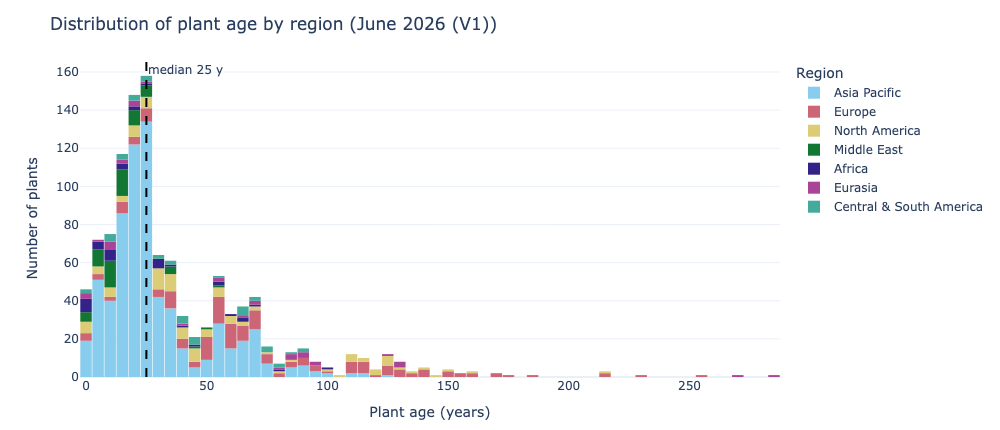

Median plant age by region:


,plants_with_age,median_age,mean_age
Region,,,
Middle East,63,14.00,15.80
Africa,39,16.00,25.90
Asia Pacific,674,23.00,28.80
Central & South America,43,40.00,43.30
North America,106,41.00,54.30
Europe,165,61.00,73.90
Eurasia,35,66.00,68.30


Five oldest plants (plausibility check of the long right tail):


,Plant name (English),Country/Area,start_year,Plant age (years),plant_status
1125,TMK Seversky Pipe plant,Russia,"1,739.00",287.00,operating
820,OMK Vyksa Casting and Rolling Complex,Russia,"1,757.00",268.99,operating
371,GLGH Resita steel plant,Romania,"1,771.00",255.00,operating
831,Otelu Rosu steel plant,Romania,"1,796.00",230.00,mothballed
211,Cleveland-Cliffs Coatesville steel plant,United States,"1,810.00",216.00,operating


In [9]:
# Distribution of `Plant age (years)`
age = steel_plants["Plant age (years)"].dropna()
print(f"Plant age is known for {age.size:,} of {len(steel_plants):,} plants ({age.size / len(steel_plants):.0%}).")
display(age.describe().to_frame("Plant age (years)").T)

age_bands = pd.cut(
    age, bins=[-0.1, 10, 25, 50, 75, 100, np.inf], labels=["0-10", "11-25", "26-50", "51-75", "76-100", ">100"]
)
display(
    age_bands.value_counts()
    .sort_index()
    .to_frame("plants")
    .assign(share=lambda t: (t["plants"] / t["plants"].sum()).map("{:.1%}".format))
)

fig_age = px.histogram(
    steel_plants.dropna(subset=["Plant age (years)"]),
    x="Plant age (years)",
    color="Region",
    nbins=60,
    labels={"count": "Number of plants"},
    title=f"Distribution of plant age by region ({GEM_RELEASE})",
    color_discrete_map=REGION_COLOURS,
    category_orders={"Region": list(REGION_COLOURS)},
    height=430,
)
fig_age.add_vline(
    x=age.median(),
    line_dash="dash",
    line_color="black",
    annotation_text=f"median {age.median():.0f} y",
    annotation_position="top right",
)
fig_age.update_layout(bargap=0.05, yaxis_title="Number of plants", legend_title_text="Region", margin=dict(t=60, b=40))
fig_age.show()

print("Median plant age by region:")
display(
    steel_plants.groupby("Region")
    .agg(
        plants_with_age=("Plant age (years)", "count"),
        median_age=("Plant age (years)", "median"),
        mean_age=("Plant age (years)", "mean"),
    )
    .sort_values("median_age")
    .round(1)
)
print("Five oldest plants (plausibility check of the long right tail):")
display(
    steel_plants.nlargest(5, "Plant age (years)")[
        ["Plant name (English)", "Country/Area", "start_year", "Plant age (years)", "plant_status"]
    ]
)

#### Answer to Question 2

- **Average plant capacity.** Across the 918 plants with operating crude steel capacity, the mean is **2,428 ttpa (2.4 Mtpa)** and the median 1,300 ttpa. The distribution is strongly right-skewed (mean/median = 1.87, 90th percentile 5,670 ttpa): a few giant integrated sites such as POSCO Gwangyang (22,999 ttpa), Angang (20,650) and Baosteel (19,800) pull the mean up, so the median is the better "typical plant".
- **Why the auxiliary columns are not added to it.** The handout suggests summing sinter, coking, pelletizing and ferronickel capacity "if needed". In this release crude steel capacity is reported directly, and those columns measure *inputs* to steelmaking (sinter, coke and pellets feed the blast furnace). Adding them to crude steel would count the same material flow several times, so they are reported separately: 175 plants have sinter capacity (835 Mtpa in total), 137 coking (229 Mtpa), 115 pelletizing (456 Mtpa) and 14 ferronickel (10 Mtpa). They are also unknown for 36 to 50% of plants.
- **Latitude and longitude.** Latitude runs from −37.83 to 67.19 and longitude from −123.16 to 174.73 (after the correction above). **94.2%** of plants are in the northern hemisphere. 1,141 locations are flagged `exact` by GEM and 152 `approximate`, which matters in Part 4 where plants are matched to 9 km grid cells.
- **Plant age.** Known for 1,125 plants (87%). Median **25 years**, mean 38.8, so again right-skewed: half of plants with known ages are 25 years old or younger (14.0% are 10 years old or less, 36.4% are 11 to 25) and 73% of those young plants are in Asia Pacific, while 7.0% are over 100 years old. Age is regional: median 14 years in the Middle East, 16 in Africa and 23 in Asia Pacific, against 61 in Europe and 66 in Eurasia. The oldest site (TMK Seversky, Russia) dates from 1739. Caveat: this is the age of the *site*; furnaces are relined or replaced many times, so an old European site is not necessarily old equipment. Site age alone does not establish remaining equipment life or transition risk.

### Question 3: Geographic Distribution
**Task:** Analyze the geographic distribution of steel plants.
- Which `Country/Area` or `Region` values have the most steel plants?
- What is the distribution of plants by `Owner` (company)?


91 countries/areas in 7 regions



,plants,share %,cumulative %
Region,,,
Asia Pacific,765,59.20,59.20
Europe,184,14.20,73.40
North America,113,8.70,82.10
Middle East,90,7.00,89.10
Africa,51,3.90,93.00
Eurasia,47,3.60,96.60
Central & South America,43,3.30,99.90


,plants,share %,cumulative %
Country/Area,,,
China,458,35.40,35.40
India,113,8.70,44.10
United States,90,7.00,51.10
Iran,56,4.30,55.40
Japan,42,3.20,58.60
Russia,31,2.40,61.00
Türkiye,30,2.30,63.30
Vietnam,28,2.20,65.50
Brazil,25,1.90,67.40


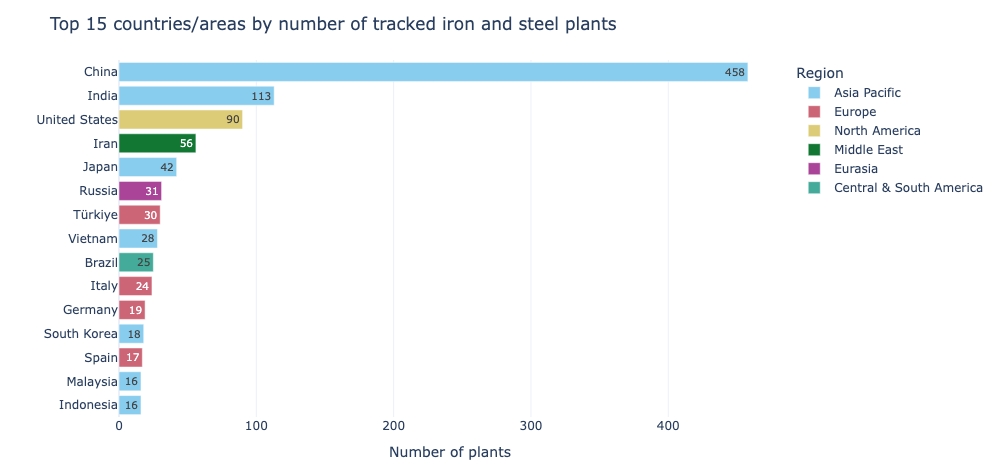

In [10]:
# Count plants by country/region


def share_table(counts: pd.Series, value_name: str) -> pd.DataFrame:
    """Turn a count/sum Series into a table with share and cumulative share."""
    table = counts.to_frame(value_name)
    table["share %"] = (table[value_name] / counts.sum() * 100).round(1)
    table["cumulative %"] = table["share %"].cumsum().round(1)
    return table


region_counts = steel_plants["Region"].value_counts()
country_counts = steel_plants["Country/Area"].value_counts()
print(f"{steel_plants['Country/Area'].nunique()} countries/areas in {steel_plants['Region'].nunique()} regions\n")
display(share_table(region_counts, "plants"))
display(share_table(country_counts, "plants").head(15))

top_countries = (
    steel_plants.groupby(["Country/Area", "Region"])
    .size()
    .rename("plants")
    .reset_index()
    .nlargest(15, "plants")
    .sort_values("plants")
)
fig_countries = px.bar(
    top_countries,
    x="plants",
    y="Country/Area",
    color="Region",
    orientation="h",
    text="plants",
    title="Top 15 countries/areas by number of tracked iron and steel plants",
    color_discrete_map=REGION_COLOURS,
    category_orders={"Region": list(REGION_COLOURS)},
    height=470,
)
fig_countries.update_layout(
    yaxis=dict(categoryorder="total ascending", title=""), xaxis_title="Number of plants", margin=dict(t=60, b=40)
)
fig_countries.show()

In [11]:
# Count plants by Owner (company)

known_owners = steel_plants[steel_plants["Owner"].str.strip().str.lower() != "unknown"]
owner_counts = known_owners["Owner"].value_counts()
print(
    f"{owner_counts.size:,} distinct owners for {len(known_owners):,} plants with known owners "
    f"({len(known_owners) / owner_counts.size:.2f} plants per owner on average)\n"
)
display(owner_counts.head(15).rename_axis("Owner").to_frame("plants"))

plants_per_owner = pd.cut(
    owner_counts,
    bins=[0, 1, 2, 5, 10, np.inf],
    labels=["1 plant", "2 plants", "3-5 plants", "6-10 plants", "more than 10"],
)
owner_distribution = plants_per_owner.value_counts().sort_index().to_frame("owners")
owner_distribution["share of owners"] = (owner_distribution["owners"] / owner_counts.size).map("{:.1%}".format)
display(owner_distribution)
print(
    f"Plants held by the 10 owners with the most plants: {owner_counts.head(10).sum() / len(steel_plants):.1%} of all plants"
)

1,068 distinct owners for 1,291 plants with known owners (1.21 plants per owner on average)



,plants
Owner,
Nucor Corp,13
Cleveland-Cliffs Inc,12
Nippon Steel Corp,10
Commercial Metals Co,8
Gerdau Ameristeel Corp,8
Steel Authority of India Ltd,8
SteelAsia Manufacturing Corp,7
ArcelorMittal Brasil SA,6
ArcelorMittal SA,6


,owners,share of owners
count,,
1 plant,962,90.1%
2 plants,69,6.5%
3-5 plants,24,2.2%
6-10 plants,11,1.0%
more than 10,2,0.2%


Plants held by the 10 owners with the most plants: 6.5% of all plants


#### Answer to Question 3

- **Countries and regions.** The tracker covers 91 countries/areas in 7 regions. **Asia Pacific has 765 plants (59.2%)**, followed by Europe (184, 14.2%) and North America (113, 8.7%). By country: **China 458 (35.4%)**, India 113 (8.7%), United States 90 (7.0%), Iran 56 (4.3%) and Japan 42 (3.2%). These five countries hold 58.6% of all plants and the top 15 hold 75.9%.
- **Owners.** Ownership is extremely fragmented at this level: **1,068 known owners for 1,291 plants**; two plants have unknown owners. 962 owners (90%) have a single plant and only 13 have more than five (Nucor 13, Cleveland-Cliffs 12, Nippon Steel 10). The ten owners with the most plants account for just 6.5% of plants.
- **Caveat on `Owner`.** GEM defines it as the *immediate* owner, which is often a plant-level subsidiary: ArcelorMittal appears as `ArcelorMittal SA`, `ArcelorMittal Brasil SA`, `ArcelorMittal Nippon Steel India Ltd`, and so on. Counting plants also says nothing about size: US electric mini-mills dominate the plant count while Asian integrated sites dominate capacity (next question). This lab aggregates immediate owners as requested; it does not infer missing parent equity shares.

### Question 4: Capacity Analysis
**Task:** Analyze the capacity distribution.
- What is the total global steel production capacity? (sum the capacity columns you are using)
- Which `Owner` values have the highest total capacity?
- How does capacity vary by `Region` or `Country/Area`?


,bucket,rows,capacity_mtpa,share %
status,,,,
operating,operating,935,"2,076.50",56.50
operating pre-retirement,operating,97,152.20,4.10
construction,pipeline,140,171.40,4.70
announced,pipeline,287,659.80,18.00
mothballed,idle,72,78.60,2.10
mothballed pre-retirement,idle,6,7.40,0.20
retired,closed,232,377.20,10.30
cancelled,closed,76,148.90,4.10


Naive sum of the capacity column (all statuses): 3,672 Mtpa
Global OPERATING crude steel capacity          : 2,229 Mtpa  <- the figure used in the rest of the lab
Development pipeline (announced + construction) : 831 Mtpa (37% of operating capacity)
Operating iron-making capacity                  : 1,660 Mtpa


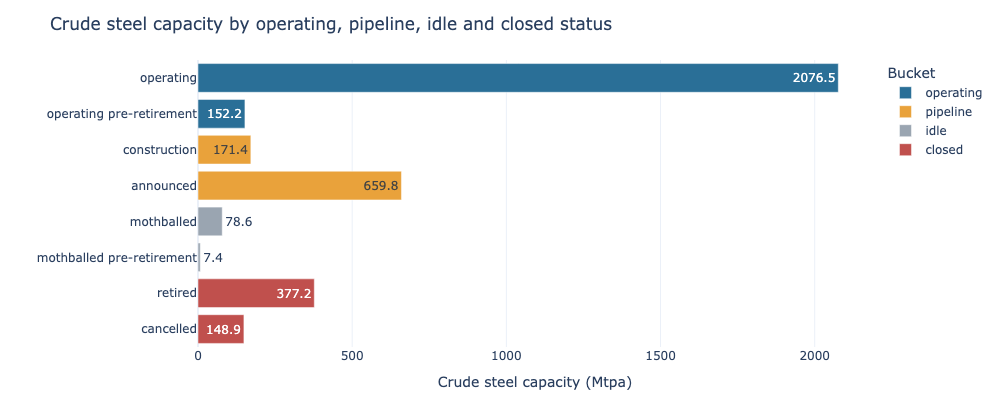

In [12]:
# Calculate total capacity

status_rows = capacity_raw.assign(
    status=capacity_raw["Status"].astype(str).str.strip().str.lower(),
    steel_ttpa=gem_number(capacity_raw[CAPACITY_COL], not_applicable_as_zero=True),
)
capacity_by_status = (
    status_rows.groupby("status")["steel_ttpa"]
    .agg(rows="size", capacity_ttpa="sum")
    .reindex(STATUS_PRIORITY)
    .dropna(how="all")
)
capacity_by_status["bucket"] = capacity_by_status.index.map(STATUS_GROUPS)
capacity_by_status["capacity_mtpa"] = (capacity_by_status["capacity_ttpa"] / 1000).round(1)
capacity_by_status["share %"] = (
    capacity_by_status["capacity_ttpa"] / capacity_by_status["capacity_ttpa"].sum() * 100
).round(1)
display(capacity_by_status[["bucket", "rows", "capacity_mtpa", "share %"]])

total_all_statuses_mtpa = capacity_by_status["capacity_ttpa"].sum() / 1000
global_operating_mtpa = steel_plants["capacity_operating_ttpa"].sum() / 1000
global_pipeline_mtpa = steel_plants["capacity_pipeline_ttpa"].sum() / 1000
print(f"Naive sum of the capacity column (all statuses): {total_all_statuses_mtpa:,.0f} Mtpa")
print(
    f"Global OPERATING crude steel capacity          : {global_operating_mtpa:,.0f} Mtpa  <- the figure used in the rest of the lab"
)
print(
    f"Development pipeline (announced + construction) : {global_pipeline_mtpa:,.0f} Mtpa ({global_pipeline_mtpa / global_operating_mtpa:.0%} of operating capacity)"
)
print(
    f"Operating iron-making capacity                  : {steel_plants['iron_capacity_operating_ttpa'].sum() / 1000:,.0f} Mtpa"
)

fig_status = px.bar(
    capacity_by_status.reset_index(),
    x="capacity_mtpa",
    y="status",
    color="bucket",
    orientation="h",
    text="capacity_mtpa",
    title="Crude steel capacity by operating, pipeline, idle and closed status",
    labels={"capacity_mtpa": "Crude steel capacity (Mtpa)", "status": "", "bucket": "Bucket"},
    color_discrete_map={"operating": "#2a6f97", "pipeline": "#e9a23b", "idle": "#9aa5b1", "closed": "#c0504d"},
    height=400,
)
fig_status.update_layout(
    yaxis=dict(categoryorder="array", categoryarray=STATUS_PRIORITY[::-1]), margin=dict(t=60, b=40)
)
fig_status.show()

,plants,countries,capacity_mtpa,share of global %
Owner,,,,
Nippon Steel Corp,10,1,44.40,1.99
POSCO Holdings Inc,2,1,41.80,1.87
Angang Steel Co Ltd,3,1,30.20,1.36
JFE Steel Corp,5,1,28.80,1.29
JSW Steel Ltd,5,1,28.40,1.27
Tata Steel Ltd,6,2,26.50,1.19
Hyundai Steel Co,4,2,24.30,1.09
Cleveland-Cliffs Inc,12,2,23.70,1.06
Steel Authority of India Ltd,8,1,21.40,0.96


Top  10 owners hold 13.0% of global operating capacity
Top  50 owners hold 33.5% of global operating capacity
Top 100 owners hold 47.8% of global operating capacity


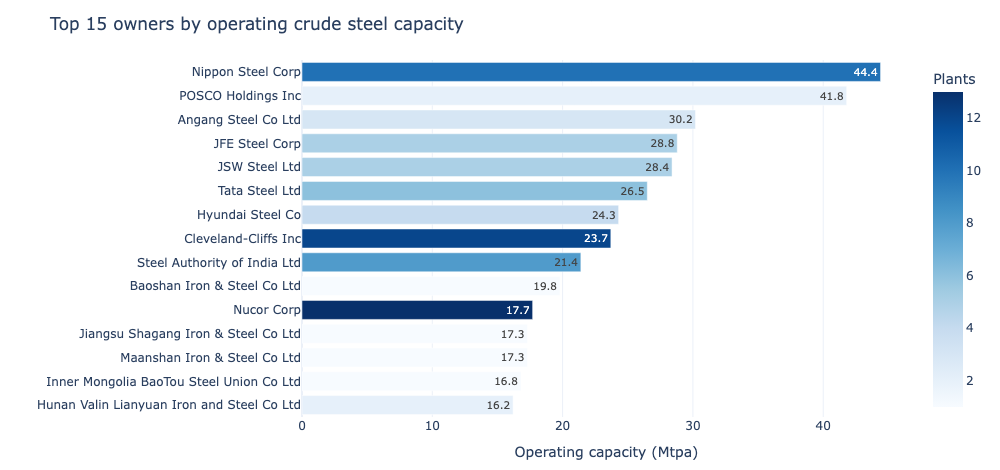

In [13]:
# Group by Owner and sum capacity

owner_capacity = (
    known_owners.groupby("Owner")
    .agg(
        plants=("Plant ID", "nunique"),
        capacity_ttpa=("capacity_operating_ttpa", lambda s: s.sum(min_count=1)),
        countries=("Country/Area", "nunique"),
    )
    .sort_values("capacity_ttpa", ascending=False)
)
owner_capacity["capacity_mtpa"] = (owner_capacity["capacity_ttpa"] / 1000).round(1)
owner_capacity["share of global %"] = (
    owner_capacity["capacity_ttpa"] / steel_plants["capacity_operating_ttpa"].sum() * 100
).round(2)
display(owner_capacity.head(15)[["plants", "countries", "capacity_mtpa", "share of global %"]])

for n in (10, 50, 100):
    print(
        f"Top {n:>3} owners hold {owner_capacity['capacity_ttpa'].head(n).sum() / steel_plants['capacity_operating_ttpa'].sum():.1%} of global operating capacity"
    )

top_owner_chart = owner_capacity.head(15).reset_index().sort_values("capacity_mtpa")
fig_owner = px.bar(
    top_owner_chart,
    x="capacity_mtpa",
    y="Owner",
    orientation="h",
    text="capacity_mtpa",
    color="plants",
    color_continuous_scale="Blues",
    title="Top 15 owners by operating crude steel capacity",
    labels={"capacity_mtpa": "Operating capacity (Mtpa)", "plants": "Plants", "Owner": ""},
    height=470,
)
fig_owner.update_layout(margin=dict(t=60, b=40))
fig_owner.show()

,plants,operating_mtpa,pipeline_mtpa,median_plant_ttpa,share of operating %
Region,,,,,
Asia Pacific,765,"1,557.80",586.70,"1,547.50",69.90
Europe,184,266.80,87.80,"1,200.00",12.00
North America,113,149.80,21.30,"1,100.00",6.70
Eurasia,47,92.90,20.40,"1,250.00",4.20
Middle East,90,68.00,80.20,"1,000.00",3.10
Central & South America,43,55.00,2.80,"1,000.00",2.50
Africa,51,38.40,31.90,830.00,1.70


,plants,operating_mtpa,pipeline_mtpa,share of operating %,pipeline / operating
Country/Area,,,,,
China,458,"1,087.90",104.10,48.80,0.10
India,113,145.50,353.10,6.50,2.43
United States,90,112.20,11.40,5.00,0.10
Japan,42,105.90,5.70,4.80,0.05
Russia,31,85.00,6.60,3.80,0.08
South Korea,18,80.90,6.00,3.60,0.07
Türkiye,30,56.30,12.20,2.50,0.22
Germany,19,44.70,14.20,2.00,0.32
Brazil,25,42.90,2.30,1.90,0.05


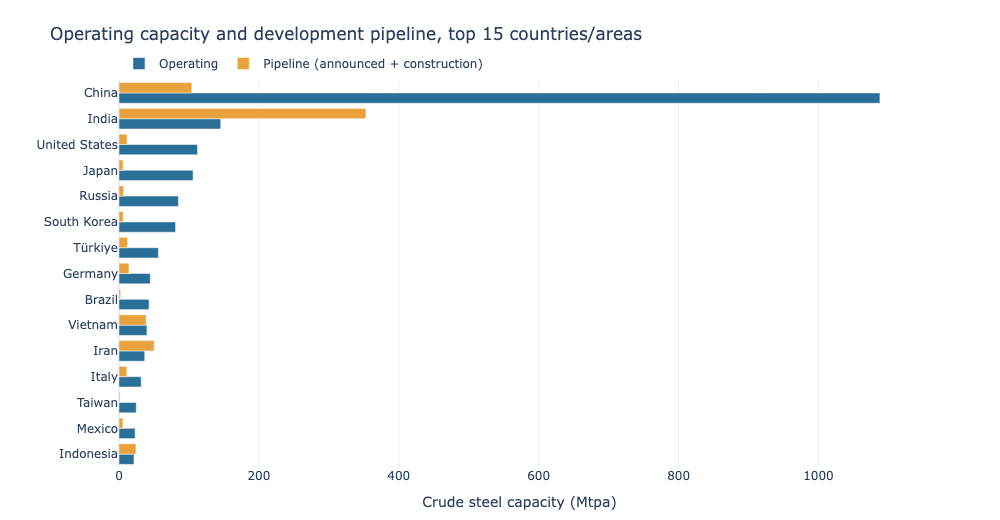

In [14]:
# How does capacity vary by Region and Country/Area?
region_capacity = (
    steel_plants.groupby("Region")
    .agg(
        plants=("Plant ID", "nunique"),
        operating_mtpa=("capacity_operating_ttpa", lambda s: s.sum() / 1000),
        pipeline_mtpa=("capacity_pipeline_ttpa", lambda s: s.sum() / 1000),
        median_plant_ttpa=("capacity_operating_ttpa", lambda s: s[s > 0].median()),
    )
    .sort_values("operating_mtpa", ascending=False)
)
region_capacity["share of operating %"] = (
    region_capacity["operating_mtpa"] / region_capacity["operating_mtpa"].sum() * 100
).round(1)
display(region_capacity.round(1))

country_capacity = (
    steel_plants.groupby("Country/Area")
    .agg(
        plants=("Plant ID", "nunique"),
        operating_mtpa=("capacity_operating_ttpa", lambda s: s.sum() / 1000),
        pipeline_mtpa=("capacity_pipeline_ttpa", lambda s: s.sum() / 1000),
    )
    .sort_values("operating_mtpa", ascending=False)
)
country_capacity["share of operating %"] = (
    country_capacity["operating_mtpa"] / country_capacity["operating_mtpa"].sum() * 100
).round(1)
country_capacity["pipeline / operating"] = (
    country_capacity["pipeline_mtpa"] / country_capacity["operating_mtpa"]
).round(2)
display(country_capacity.head(15).round({"operating_mtpa": 1, "pipeline_mtpa": 1}))

capacity_long = (
    country_capacity.head(15)
    .reset_index()
    .melt(
        id_vars="Country/Area",
        value_vars=["operating_mtpa", "pipeline_mtpa"],
        var_name="bucket",
        value_name="capacity_mtpa",
    )
)
capacity_long["bucket"] = capacity_long["bucket"].map(
    {"operating_mtpa": "Operating", "pipeline_mtpa": "Pipeline (announced + construction)"}
)
fig_country_capacity = px.bar(
    capacity_long,
    x="capacity_mtpa",
    y="Country/Area",
    color="bucket",
    orientation="h",
    barmode="group",
    title="Operating capacity and development pipeline, top 15 countries/areas",
    labels={"capacity_mtpa": "Crude steel capacity (Mtpa)", "bucket": "", "Country/Area": ""},
    color_discrete_map={"Operating": "#2a6f97", "Pipeline (announced + construction)": "#e9a23b"},
    height=520,
)
fig_country_capacity.update_layout(
    yaxis=dict(categoryorder="array", categoryarray=country_capacity.head(15).index[::-1].tolist()),
    legend=dict(orientation="h", y=1.08, x=0),
    margin=dict(t=80, b=40),
)
fig_country_capacity.show()

#### Answer to Question 4

- **Total capacity.** Summing the capacity column over all rows gives 3,672 Mtpa. This mixes statuses: only **2,229 Mtpa (60.7%) is operating today** (2,077 operating plus 152 operating pre-retirement). 831 Mtpa is in the pipeline (660 announced, 171 under construction), 86 Mtpa is mothballed and 526 Mtpa is retired or cancelled. Operating iron-making capacity is 1,660 Mtpa. These are reported capacities in the tracker; unknown magnitudes are excluded from totals.
- **Owners with the highest capacity.** Nippon Steel Corp (44.4 Mtpa, 2.0% of the world total), POSCO Holdings (41.8), Angang Steel (30.2), JFE Steel (28.8) and JSW Steel (28.4). Concentration is low: the top 10 owners hold 13.0% of operating capacity, the top 50 hold 33.5% and the top 100 hold 47.8%. POSCO reaches second place with only two plants, which shows how different plant counts and capacity are.
- **By region and country.** Asia Pacific holds **69.9%** of operating capacity (1,558 Mtpa) and China alone **48.8%** (1,088 Mtpa), more than the next 14 countries combined (851 Mtpa). India follows with 145.5 Mtpa, then the United States (112.2), Japan (105.9), Russia (85.0) and South Korea (80.9 Mtpa from only 18 plants). The pipeline tells a different story: **India has 353 Mtpa announced or under construction, 2.4 times its operating base**, while China's pipeline is only 0.1 times its base. Iran (1.4x), Indonesia (1.1x) and Vietnam (1.0x) would also roughly double if everything announced were built. The typical operating plant is largest in Asia Pacific (median 1,548 ttpa) and smallest in Africa (830 ttpa).
- **Why it matters for climate risk.** Future capacity growth is concentrated in India and South-East Asia, so its technology mix matters for future emissions. These capacity data alone do not quantify emissions or climate losses.

---
## Part 3: Geospatial Visualization with Plotly

Create interactive maps to visualize the steel plants' locations and characteristics.


### Exercise 1: Basic Scatter Map
**Task:** Create a scatter map showing all steel plant locations.
- Parse `Coordinates` into numeric `Latitude` and `Longitude` (see hint in the code cell)
- Color points by `Country/Area` or `Region`
- Add hover information showing `Plant name (English)`, `Owner`, and capacity


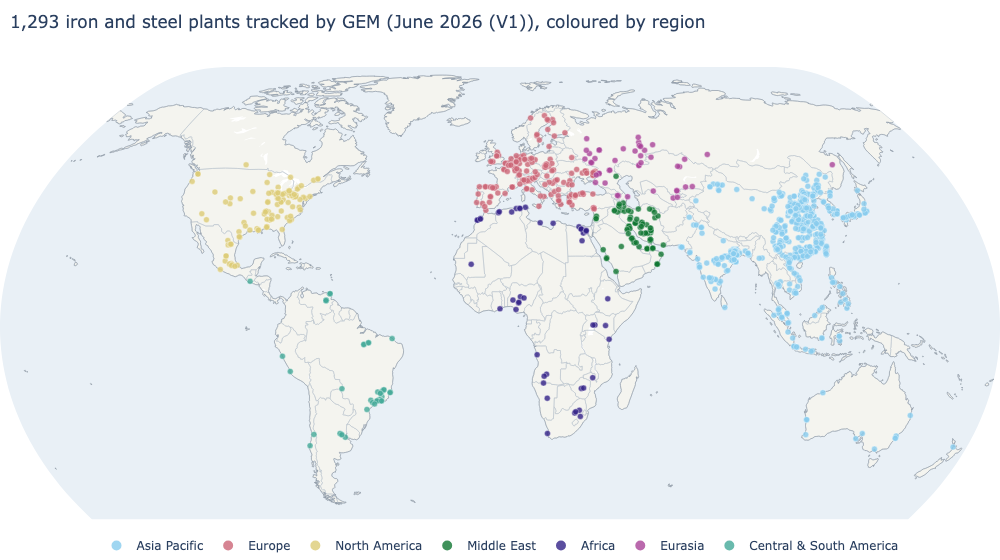

In [15]:
# Create a scatter_geo or scatter_mapbox plot
# Hint: Use plotly.express.scatter_geo() or scatter_mapbox()
#
# Coordinates hint:
#   The dataset usually stores location in a single Coordinates column like "lat, lon".
#   Split it before plotting

HOVER_LABELS = {
    "capacity_label": "Operating capacity",
    "capacity_operating_ttpa": "Operating capacity (ttpa)",
    "plant_status": "Status",
    "owner_group": "Owner",
}


def style_world_map(fig: go.Figure, title: str, height: int = 560) -> go.Figure:
    """Shared look for the world maps: natural-earth projection, light land/ocean colours, no Antarctica."""
    fig.update_geos(
        projection_type="natural earth",
        lataxis_range=[-58, 82],
        showframe=False,
        showcountries=True,
        countrycolor="#b8c2cc",
        countrywidth=0.5,
        showland=True,
        landcolor="#f4f4ef",
        showocean=True,
        oceancolor="#e9f0f6",
        coastlinecolor="#8a96a3",
        coastlinewidth=0.6,
    )
    fig.update_layout(
        title=dict(text=title, x=0.01, font=dict(size=17)),
        height=height,
        margin=dict(l=0, r=0, t=55, b=0),
        legend=dict(
            itemsizing="constant", orientation="h", x=0.5, xanchor="center", y=-0.02, yanchor="top", title_text=""
        ),
    )
    return fig


# `Latitude` / `Longitude` were parsed from the single "lat, lon" text column in Part 2 (parse_coordinates).
# Readable capacity text for the hover box (avoids showing "NaN" for plants without an operating figure).
steel_plants["capacity_label"] = np.select(
    [steel_plants["capacity_operating_ttpa"] > 0, steel_plants["capacity_operating_ttpa"].isna()],
    [steel_plants["capacity_operating_ttpa"].map("{:,.0f} ttpa".format), "operating, size unknown"],
    default="no operating steel capacity",
)
operating_plants = steel_plants[steel_plants["capacity_operating_ttpa"] > 0].copy()

fig_plants = px.scatter_geo(
    steel_plants,
    lat="Latitude",
    lon="Longitude",
    color="Region",
    hover_name="Plant name (English)",
    hover_data={
        "Owner": True,
        "Country/Area": True,
        "capacity_label": True,
        "plant_status": True,
        "Region": False,
        "Latitude": ":.3f",
        "Longitude": ":.3f",
    },
    labels=HOVER_LABELS,
    category_orders={"Region": list(REGION_COLOURS)},
    color_discrete_map=REGION_COLOURS,
    opacity=0.8,
)
fig_plants.update_traces(marker=dict(size=6, line=dict(width=0.4, color="white")))
style_world_map(
    fig_plants, f"{len(steel_plants):,} iron and steel plants tracked by GEM ({GEM_RELEASE}), coloured by region"
)
fig_plants.show()

**Reading the map.** `scatter_geo` is used for the world views: it needs no map tiles and therefore renders everywhere, including the static copy. All 1,293 plants are shown, whatever their status. The belt from the Indian subcontinent through eastern China to Korea and Japan stands out, then Europe and the eastern United States. Africa, South America and Oceania are almost empty. Hovering shows the plant name, owner, country, operating capacity and status.

### Exercise 2: Sized Markers by Capacity
**Task:** Create a map where marker size represents plant capacity.
- Larger markers for higher capacity plants
- Color by `Owner`
- Include interactive hover details (`Plant name (English)`, `Country/Area`, capacity, etc.)


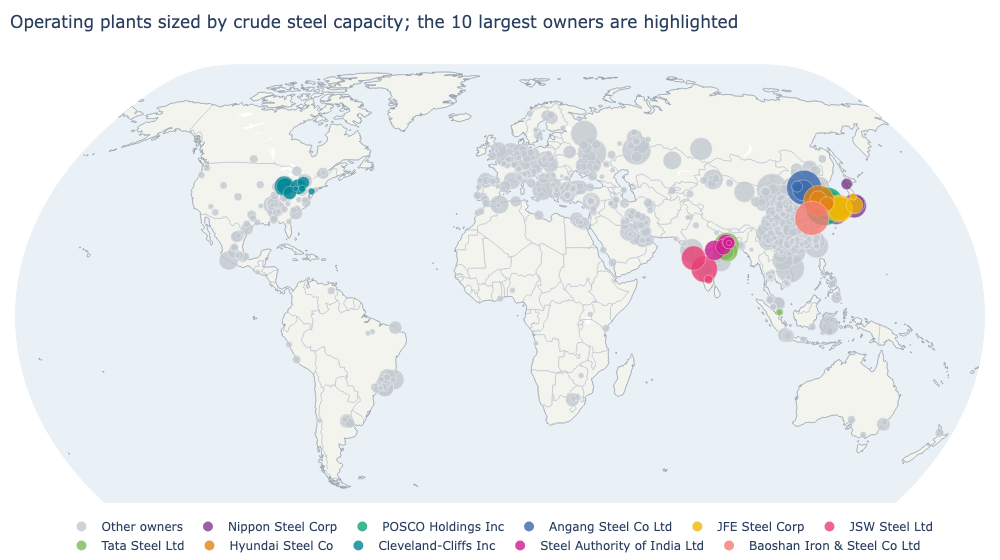

918 operating plants shown. The 10 highlighted owners run 44 of them (13.0% of capacity).


In [16]:
# Create scatter map with size parameter based on capacity

TOP_N_OWNERS = 10  # colouring ~1,000 owners individually would be unreadable: highlight the largest, grey out the rest
top_owners = owner_capacity.head(TOP_N_OWNERS).index.tolist()

sized_plants = operating_plants.assign(
    owner_group=lambda t: t["Owner"].where(t["Owner"].isin(top_owners), "Other owners")
)
sized_plants = sized_plants.sort_values(
    "capacity_operating_ttpa", ascending=False
)  # small markers drawn on top of big ones
owner_palette = dict(zip(top_owners, px.colors.qualitative.Bold + px.colors.qualitative.Vivid))
owner_palette["Other owners"] = "#c3c9d1"

fig_sized = px.scatter_geo(
    sized_plants,
    lat="Latitude",
    lon="Longitude",
    size="capacity_operating_ttpa",
    size_max=26,
    color="owner_group",
    hover_name="Plant name (English)",
    hover_data={
        "Owner": True,
        "Country/Area": True,
        "capacity_operating_ttpa": ":,.0f",
        "plant_status": True,
        "owner_group": False,
        "Latitude": False,
        "Longitude": False,
    },
    labels=HOVER_LABELS,
    category_orders={"owner_group": ["Other owners"] + top_owners},
    color_discrete_map=owner_palette,
    opacity=0.8,
)
fig_sized.update_traces(marker=dict(line=dict(width=0.4, color="white")))
style_world_map(
    fig_sized, f"Operating plants sized by crude steel capacity; the {TOP_N_OWNERS} largest owners are highlighted"
)
fig_sized.show()

print(
    f"{len(sized_plants):,} operating plants shown. The {TOP_N_OWNERS} highlighted owners run "
    f"{sized_plants['owner_group'].ne('Other owners').sum()} of them "
    f"({sized_plants.loc[sized_plants['owner_group'].ne('Other owners'), 'capacity_operating_ttpa'].sum() / sized_plants['capacity_operating_ttpa'].sum():.1%} of capacity)."
)

**Design choices.** Marker *area* (not diameter) is proportional to operating capacity, so a plant twice as large looks twice as big. Colouring by `Owner` literally would need more than 1,000 colours, so the ten largest owners are highlighted and the rest are grey; every owner remains visible on hover. The largest markers form an arc along the Chinese coast and the Yangtze, around Tokyo and Osaka bays, on Korea's south coast and in eastern India: large integrated plants sit on deep-water coasts and rivers because they import iron ore and coking coal by ship. The ten highlighted owners operate 44 plants, 13% of world capacity.

### Exercise 3: Density Heatmap
**Task:** Create a density map showing concentration of steel plants.
- Use Plotly's density_mapbox to show clustering
- Identify regions with high plant density


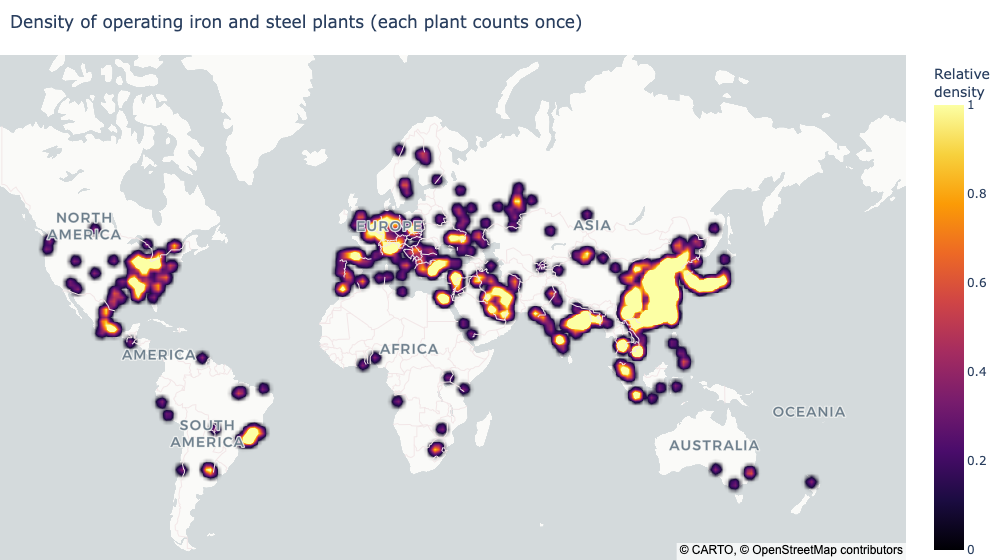

Provinces/states with the most operating plants:


plants  capacity_mtpa  share of world plants %
Country/Area Subnational unit (province/state)                                                
China        Hebei                                  57         230.50                     6.20
             Guangdong                              39          66.90                     4.20
             Jiangsu                                29         114.20                     3.20
India        Odisha                                 19          43.60                     2.10
China        Shanxi                                 19          58.80                     2.10
             Fujian                                 17          41.40                     1.90
             Guangxi                                17          56.00                     1.90
             Liaoning                               17          76.80                     1.90
             Shandong                               17          63.40                     1.90
             Henan                                  14          31.90                     1.50

Densest 5x5 degree cells (south-west corner given):


plants  capacity_mtpa main_country
lat_cell lon_cell                                    
35       115           52         229.90        China
         110           45         135.70        China
20       110           42          79.90        China
30       115           34         102.00        China
20       85            28          48.30        India
         80            19          40.50        India
25       115           19          47.40        China
45       10            17          23.00        Italy

The 8 densest cells hold 28% of all operating plants.


In [17]:
# Create density heatmap
# Hint: Use plotly.express.density_mapbox()

fig_density = density_map_fn(
    operating_plants,
    lat="Latitude",
    lon="Longitude",
    radius=9,
    zoom=0.85,
    center={"lat": 27, "lon": 35},
    hover_name="Plant name (English)",
    hover_data={"Country/Area": True, "capacity_label": True, "Latitude": False, "Longitude": False},
    labels=HOVER_LABELS,
    color_continuous_scale="Inferno",
    height=560,
    map_style="carto-positron",
)
fig_density.update_layout(
    title=dict(text="Density of operating iron and steel plants (each plant counts once)", x=0.01, font=dict(size=17)),
    margin=dict(l=0, r=0, t=55, b=0),
    coloraxis_colorbar=dict(title=dict(text="Relative<br>density")),
)
fig_density.show()

# Put numbers on the hot spots seen on the map: provinces/states, then a coarse 5-degree grid (independent of borders)
PROVINCE_COL = "Subnational unit (province/state)"
if PROVINCE_COL in operating_plants.columns:
    hotspots = (
        operating_plants.groupby(["Country/Area", PROVINCE_COL])
        .agg(
            plants=("Plant ID", "nunique"),
            capacity_mtpa=("capacity_operating_ttpa", lambda s: round(s.sum() / 1000, 1)),
        )
        .sort_values("plants", ascending=False)
    )
    hotspots["share of world plants %"] = (hotspots["plants"] / len(operating_plants) * 100).round(1)
    print("Provinces/states with the most operating plants:")
    display(hotspots.head(10))

GRID_DEG = 5
cells = operating_plants.assign(
    lat_cell=(np.floor(operating_plants["Latitude"] / GRID_DEG) * GRID_DEG).astype(int),
    lon_cell=(np.floor(operating_plants["Longitude"] / GRID_DEG) * GRID_DEG).astype(int),
)
grid_hotspots = (
    cells.groupby(["lat_cell", "lon_cell"])
    .agg(
        plants=("Plant ID", "nunique"),
        capacity_mtpa=("capacity_operating_ttpa", lambda s: round(s.sum() / 1000, 1)),
        main_country=("Country/Area", lambda s: s.value_counts().index[0]),
    )
    .sort_values("plants", ascending=False)
)
print(f"Densest {GRID_DEG}x{GRID_DEG} degree cells (south-west corner given):")
display(grid_hotspots.head(8))
print(
    f"The 8 densest cells hold {grid_hotspots['plants'].head(8).sum() / len(operating_plants):.0%} of all operating plants."
)

#### Interpretation: where are plants concentrated?

The heatmap counts plants (each plant weighs 1), so it shows where *sites* cluster, not where capacity is. The tables under the map put numbers on the bright areas:

- **Northern China is the densest steel region in the world.** Hebei province alone has 57 operating plants and 230 Mtpa, about 10% of world operating capacity in one province. The densest 5-degree cell (southern Hebei, western Shandong, Tianjin) contains 52 plants and 230 Mtpa. Guangdong (39 plants) and Jiangsu (29 plants, 114 Mtpa) follow.
- **Eastern India is the second hot spot**: two neighbouring cells hold 28 and 19 plants across West Bengal, Odisha, Jharkhand and Chhattisgarh. Odisha alone has 19 plants.
- **Northern Italy is the only non-Asian area in the top eight cells**: 17 plants, 14 of them Italian and 16 of them electric (EAF) sites. They are small: the cell holds only 23 Mtpa, one tenth of the Hebei cell. Density and capacity are different things, which is why the dashboard offers a capacity-weighted version of this map.
- The eight densest cells hold 28% of all operating plants. A physical hazard (flood, heat, water stress) or a regional policy hitting one of these cells affects a large share of the fleet at once: geographic concentration is itself a risk factor.

---
## Part 4: Merging Exposure / Population Data with Assets

Steel plants sit near people, housing, and economic activity. In this part you will attach **granular socio-economic exposure data** to each plant so you can ask: *who and what is near this industrial asset?*

We use **LitPop** (ETH Zurich): a global dataset that combines **population** and **produced capital / asset value** on a fine geographic grid. It is widely used in disaster- and climate-risk analysis as a measure of **exposure**. It is **not** classical environmental monitoring (not air quality, emissions, or weather).

**Goal:** spatially link LitPop grid cells (or sample points) to steel plant locations (nearest neighbor or spatial join), then use the merged fields in maps and later company-level summaries.


### Exercise 1: Load LitPop (Exposure) Data
**Task:** Load the LitPop sample and inspect it.

- **Samples for this lab (recommended):** LitPop sample files are available on Moodle (litpop data). Use these for the merge exercises below.
- **Full LitPop dataset (optional):** [ETH Research Collection - LitPop](https://www.research-collection.ethz.ch/entities/researchdata/12dcfc4f-9d03-463a-8d6b-76c0dc73cdc8)

- Expected columns (may vary by extract): location identifiers, latitude, longitude, population and/or asset-value / exposure fields, etc.

Briefly note what each column represents and the spatial resolution of the sample.


In [18]:
# Load LitPop sample (exposure / population-asset data)


def read_litpop_file(path: Path) -> tuple[pd.DataFrame, str]:
    """Read one CLIMADA LitPop file with h5py and return (table, description stored in the file).

    The file is a pandas "fixed" HDF5 store: the DataFrame sits under /exposures as typed blocks. We read the
    numeric blocks only. The `geometry` block holds pickled shapely points: loading it would require
    PyTables + shapely/geopandas, and it only duplicates the latitude/longitude columns.
    """
    with h5py.File(path, "r") as h5:
        group = h5["exposures"]
        if not isinstance(group, h5py.Group):
            raise ValueError(f"Expected an exposures group in {path.name}")
        blocks = []
        for block in range(int(np.asarray(group.attrs["nblocks"]).item())):
            values = group[f"block{block}_values"]
            items = group[f"block{block}_items"]
            if not isinstance(values, h5py.Dataset) or not isinstance(items, h5py.Dataset):
                raise ValueError(f"Invalid exposure block {block} in {path.name}")
            if values.dtype.kind not in "fiu":  # not float/int: the pickled geometry column
                continue
            names = [name.decode() for name in items[:]]
            blocks.append(pd.DataFrame(values[:], columns=names))
        raw_metadata = np.asarray(group.attrs["metadata"]).tobytes() if "metadata" in group.attrs else b""
    description = re.search(rb"LitPop Exposure for .*?admin1_calc: \w+", raw_metadata)
    return pd.concat(blocks, axis=1), (description.group(0).decode() if description else "no description stored")


litpop_files = sorted(LITPOP_DIR.glob("LitPop_*.hdf5"))
if not litpop_files:
    raise FileNotFoundError(
        "No LitPop .hdf5 files found. Extract the Moodle sample into litpop/ or data/ next to this notebook."
    )

litpop_parts, litpop_descriptions = [], {}
for path in litpop_files:
    table, description = read_litpop_file(path)
    country_match = re.search(r"_([A-Z]{3})_v\d", path.name)
    if country_match is None:
        raise ValueError(f"Missing country code in LitPop filename: {path.name}")
    iso3 = country_match.group(1)
    litpop_parts.append(table.assign(iso3=iso3))
    litpop_descriptions[iso3] = description
    print(f"{path.name}: {len(table):>8,} grid cells | {description}")

litpop = pd.concat(litpop_parts, ignore_index=True)
print(f"\nCombined LitPop sample: {len(litpop):,} grid cells x {litpop.shape[1]} columns")
display(litpop.head())

LitPop_pc_300_arcsec_CHN_v1.hdf5:  136,991 grid cells | LitPop Exposure for ['CHN'] at 300 as, year: 2018, financial mode: pc, exp: (1, 1), admin1_calc: False
LitPop_pc_300_arcsec_IND_v1.hdf5:   40,101 grid cells | LitPop Exposure for ['IND'] at 300 as, year: 2018, financial mode: pc, exp: (1, 1), admin1_calc: False
LitPop_pc_300_arcsec_JPN_v1.hdf5:    5,499 grid cells | LitPop Exposure for ['JPN'] at 300 as, year: 2018, financial mode: pc, exp: (1, 1), admin1_calc: False

Combined LitPop sample: 182,591 grid cells x 6 columns


,value,latitude,longitude,region_id,impf_,iso3
0,"5,280,439,584.86",20.04,110.21,156,1,CHN
1,"40,405,586.87",20.04,110.62,156,1,CHN
2,"41,902,243.33",20.04,110.71,156,1,CHN
3,"88,138,720.42",19.96,109.54,156,1,CHN
4,"187,994,709.31",19.96,109.62,156,1,CHN


In [19]:
# Inspect LitPop data (columns, dtypes, missing values, value ranges)

litpop.info()
print("\nMissing values per column:", litpop.isna().sum().to_dict())
print(
    "Negative values:", int((litpop["value"] < 0).sum()), "| distinct impf_ values:", litpop["impf_"].unique().tolist()
)
display(litpop[["value", "latitude", "longitude"]].describe().T)

# Spatial resolution, measured from the data: smallest step between distinct cell-centre latitudes
step_deg = float(np.diff(np.sort(litpop["latitude"].unique())).min())
mid_lat = float(litpop["latitude"].median())
print(
    f"Grid step: {step_deg:.5f} degrees = {step_deg * 3600:.0f} arc-seconds "
    f"(about {step_deg * 111.2:.1f} km north-south, {step_deg * 111.2 * np.cos(np.deg2rad(mid_lat)):.1f} km east-west at {mid_lat:.0f}N)"
)

country_summary = litpop.groupby("iso3").agg(
    region_id=("region_id", "first"),
    cells=("value", "size"),
    total_usd_trn=("value", lambda v: v.sum() / 1e12),
    zero_value_cells=("value", lambda v: int((v == 0).sum())),
    median_cell_usd_m=("value", lambda v: v.median() / 1e6),
    p99_cell_usd_bn=("value", lambda v: v.quantile(0.99) / 1e9),
    max_cell_usd_bn=("value", lambda v: v.max() / 1e9),
    lat_min=("latitude", "min"),
    lat_max=("latitude", "max"),
    lon_min=("longitude", "min"),
    lon_max=("longitude", "max"),
)
display(country_summary.round(2))

top_1pct_share = litpop.groupby("iso3")["value"].apply(lambda v: v.nlargest(max(1, len(v) // 100)).sum() / v.sum())
print("Share of national asset value held by the top 1% of cells:", top_1pct_share.map("{:.0%}".format).to_dict())

<class 'pandas.DataFrame'>
RangeIndex: 182591 entries, 0 to 182590
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   value      182591 non-null  float64
 1   latitude   182591 non-null  float64
 2   longitude  182591 non-null  float64
 3   region_id  182591 non-null  int64  
 4   impf_      182591 non-null  int64  
 5   iso3       182591 non-null  str    
dtypes: float64(3), int64(2), str(1)
memory usage: 8.9 MB

Missing values per column: {'value': 0, 'latitude': 0, 'longitude': 0, 'region_id': 0, 'impf_': 0, 'iso3': 0}
Negative values: 0 | distinct impf_ values: [1]


,count,mean,std,min,25%,50%,75%,max
value,"182,591.00","381,785,614.93","5,670,982,325.94",0.00,"50,235.80","1,295,842.70","14,017,626.95","504,405,695,271.74"
latitude,"182,591.00",33.59,8.82,6.88,27.04,33.88,40.38,53.54
longitude,"182,591.00",99.54,17.57,68.21,83.88,98.71,113.88,145.79


Grid step: 0.08333 degrees = 300 arc-seconds (about 9.3 km north-south, 7.7 km east-west at 34N)


,region_id,cells,total_usd_trn,zero_value_cells,median_cell_usd_m,p99_cell_usd_bn,max_cell_usd_bn,lat_min,lat_max,lon_min,lon_max
iso3,,,,,,,,,,,
CHN,156,136991,39.32,17641,0.38,5.19,287.35,18.21,53.54,73.62,134.71
IND,356,40101,6.84,0,14.46,2.17,51.93,6.88,35.46,68.21,97.29
JPN,392,5499,23.55,0,24.61,109.85,504.41,24.29,45.46,122.96,145.79


Share of national asset value held by the top 1% of cells: {'CHN': '77%', 'IND': '42%', 'JPN': '54%'}


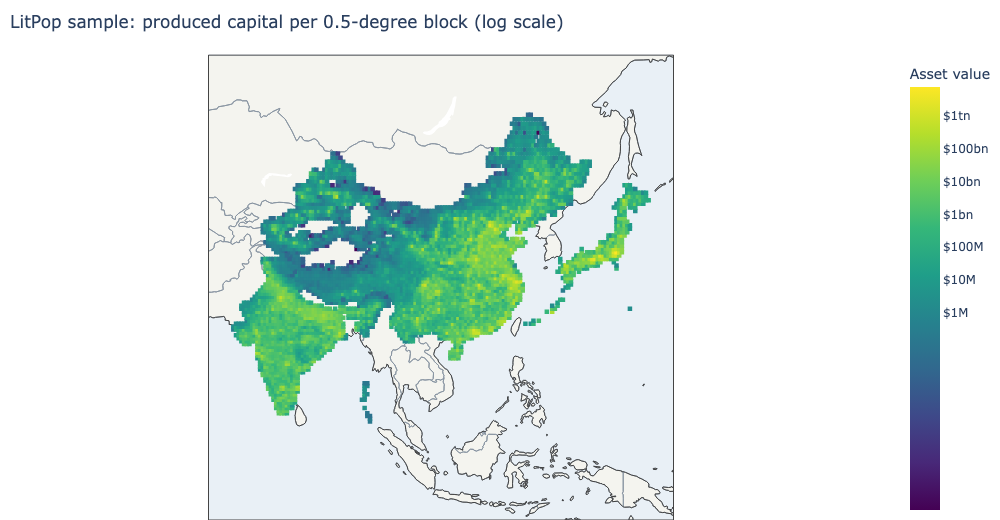

In [20]:
# Quick look at the exposure layer itself. 180k cells are too many for a browser map, so the preview sums the
# 300-arcsec cells into 0.5-degree blocks (the analysis below still uses the full-resolution cells).
PREVIEW_DEG = 0.5
USD_TICKS = {6: "$1M", 7: "$10M", 8: "$100M", 9: "$1bn", 10: "$10bn", 11: "$100bn", 12: "$1tn", 13: "$10tn"}

litpop_grid = (
    litpop.assign(
        lat_bin=np.floor(litpop["latitude"] / PREVIEW_DEG) * PREVIEW_DEG + PREVIEW_DEG / 2,
        lon_bin=np.floor(litpop["longitude"] / PREVIEW_DEG) * PREVIEW_DEG + PREVIEW_DEG / 2,
    )
    .groupby(["iso3", "lat_bin", "lon_bin"], as_index=False)["value"]
    .sum()
    .query("value > 0")
)
litpop_grid["value"] = litpop_grid["value"].round(0)
litpop_grid["log10_value"] = np.log10(litpop_grid["value"]).round(3)

fig_litpop = px.scatter_geo(
    litpop_grid,
    lat="lat_bin",
    lon="lon_bin",
    color="log10_value",
    color_continuous_scale="Viridis",
    hover_data={"iso3": True, "value": ":,.0f", "log10_value": False, "lat_bin": False, "lon_bin": False},
    labels={"value": "Asset value (USD)", "iso3": "Country"},
)
fig_litpop.update_traces(marker=dict(size=4.5, symbol="square", line=dict(width=0)))
fig_litpop.update_geos(
    fitbounds="locations",
    showcountries=True,
    countrycolor="#8a96a3",
    showland=True,
    landcolor="#f4f4ef",
    showocean=True,
    oceancolor="#e9f0f6",
    projection_type="mercator",
)
tick_values = [v for v in USD_TICKS if litpop_grid["log10_value"].min() - 1 < v < litpop_grid["log10_value"].max() + 1]
fig_litpop.update_layout(
    title=dict(
        text=f"LitPop sample: produced capital per {PREVIEW_DEG}-degree block (log scale)", x=0.01, font=dict(size=17)
    ),
    height=520,
    margin=dict(l=0, r=0, t=55, b=0),
    coloraxis_colorbar=dict(
        title=dict(text="Asset value"), tickvals=tick_values, ticktext=[USD_TICKS[v] for v in tick_values]
    ),
)
fig_litpop.show()

#### What the LitPop sample contains

Three HDF5 files written by CLIMADA (one per country: China, India, Japan), 182,591 grid cells in total. The description stored inside each file reads: *LitPop Exposure at 300 as, year: 2018, financial mode: pc, exp: (1, 1)*.

| Column | Meaning |
|---|---|
| `value` | Asset value of the grid cell in **USD**. National produced capital (financial mode `pc`) is spread over the grid in proportion to night-light intensity x population (exponents 1, 1), reference year 2018. This is our exposure metric. |
| `latitude`, `longitude` | Centre of the grid cell, WGS84 degrees. |
| `region_id` | ISO 3166-1 numeric country code (156 China, 356 India, 392 Japan). |
| `impf_` | Identifier of the CLIMADA impact (damage) function attached to the cell. It is 1 everywhere and is not used here. |
| `geometry` | The same point as a shapely object (pickled). Not loaded: it duplicates latitude/longitude. |
| `iso3` | Added by us from the file name. |

**Spatial resolution.** Measured from the data, the grid step is 0.08333 degrees = **300 arc-seconds**, about 9.3 km north to south and 7.7 km east to west at 34°N. The published LitPop archive is at 30 arc-seconds, so this course sample is a 10 times coarser aggregation.

**What it is, and is not.** There is no separate population column: population enters only through the weighting. `value` is a modelled estimate of where physical assets are, not an observation, and not an environmental variable. Values are extremely concentrated: the top 1% of cells hold 77% of the asset value in China, 54% in Japan and 42% in India, and 17,641 Chinese cells (deserts, mountains) are worth zero. That skew is why exposure is shown on a log scale below.

Source: Eberenz et al. (2020), *Asset exposure data for global physical risk assessment*, Earth Syst. Sci. Data 12, 817-833, https://doi.org/10.5194/essd-12-817-2020.

### Exercise 2: Spatial Join or Nearest Neighbor Matching
**Task:** Attach LitPop exposure attributes to each steel plant based on geographic proximity.
- Match each plant to the **nearest LitPop grid cell / sample point** (or use a spatial join if you work with polygons)
- Consider `geopandas`, a ball-tree / KD-tree nearest-neighbor search, or haversine distances
- Keep plant identifiers and the LitPop fields you will use later (e.g. population, asset value / exposure)

You should end up with one row per plant (or a clear many-to-one rule if you aggregate nearby cells).


In [21]:
# Matching tolerance = one cell diagonal (~13 km at the equator). A plant inside a cell is at most half a diagonal from
# its centre, so this accepts the plant's own cell or a direct neighbour (coastal plants on reclaimed land often sit
# where LitPop has no cell) and rejects anything farther away.
CELL_DIAGONAL_KM = float(np.hypot(step_deg, step_deg) * 111.2)
MAX_MATCH_DISTANCE_KM = round(CELL_DIAGONAL_KM, 1)
NEIGHBOURHOOD_RADIUS_KM = 25.0  # many-to-one rule: sum every cell whose centre lies within 25 km of the plant
LITPOP_COUNTRY_NAMES = {"CHN": "China", "IND": "India", "JPN": "Japan"}  # LitPop ISO3 code -> GEM `Country/Area`


def build_cell_tree(cells: pd.DataFrame) -> BallTree:
    """Ball tree over the cell centres. The haversine metric expects [latitude, longitude] in radians."""
    return BallTree(np.deg2rad(cells[["latitude", "longitude"]].to_numpy()), metric="haversine")


def match_nearest_cell(plants: pd.DataFrame, cells: pd.DataFrame, tree: BallTree) -> pd.DataFrame:
    """For every plant, find the closest LitPop cell centre and return its attributes and the distance in km."""
    plant_radians = np.deg2rad(plants[["Latitude", "Longitude"]].to_numpy())
    distance_rad, position = tree.query(plant_radians, k=1)
    nearest = cells.iloc[position[:, 0]]
    return pd.DataFrame(
        {
            "litpop_iso3": nearest["iso3"].to_numpy(),
            "litpop_cell_lat": nearest["latitude"].to_numpy(),
            "litpop_cell_lon": nearest["longitude"].to_numpy(),
            "litpop_distance_km": distance_rad[:, 0] * EARTH_RADIUS_KM,
            "litpop_value_nearest_usd": nearest["value"].to_numpy(),
        },
        index=plants.index,
    )


def sum_cells_within_radius(
    plants: pd.DataFrame, cells: pd.DataFrame, tree: BallTree, radius_km: float
) -> pd.DataFrame:
    """Sum the asset value of all cells whose centre lies within `radius_km` of each plant."""
    plant_radians = np.deg2rad(plants[["Latitude", "Longitude"]].to_numpy())
    neighbours = tree.query_radius(plant_radians, r=radius_km / EARTH_RADIUS_KM)
    values = cells["value"].to_numpy()
    return pd.DataFrame(
        {
            "litpop_value_25km_usd": [values[idx].sum() for idx in neighbours],
            "litpop_cells_25km": [len(idx) for idx in neighbours],
        },
        index=plants.index,
    )


start = time.perf_counter()
cell_tree = build_cell_tree(litpop)
nearest_cells = match_nearest_cell(steel_plants, litpop, cell_tree)
neighbourhoods = sum_cells_within_radius(steel_plants, litpop, cell_tree, NEIGHBOURHOOD_RADIUS_KM)
print(f"Matched {len(steel_plants):,} plants against {len(litpop):,} cells in {time.perf_counter() - start:.2f} s")

# Independent check of the tree result with the explicit haversine formula
check_km = haversine_km(
    steel_plants["Latitude"],
    steel_plants["Longitude"],
    nearest_cells["litpop_cell_lat"],
    nearest_cells["litpop_cell_lon"],
)
assert np.allclose(check_km, nearest_cells["litpop_distance_km"], atol=1e-6), (
    "BallTree and haversine distances disagree"
)

in_sample_country = steel_plants["Country/Area"].isin(LITPOP_COUNTRY_NAMES.values())
print("\nDistance to the nearest LitPop cell centre (km):")
display(
    pd.DataFrame(
        {
            "plants in China / India / Japan": nearest_cells.loc[in_sample_country, "litpop_distance_km"].describe(
                percentiles=[0.5, 0.9, 0.99]
            ),
            "plants elsewhere": nearest_cells.loc[~in_sample_country, "litpop_distance_km"].describe(
                percentiles=[0.5, 0.9, 0.99]
            ),
        }
    ).round(2)
)
print(
    f"A point inside a cell is at most {CELL_DIAGONAL_KM / 2:.1f} km from its centre (half the cell diagonal at the equator); "
    f"matching tolerance = {MAX_MATCH_DISTANCE_KM} km."
)

Matched 1,293 plants against 182,591 cells in 0.06 s

Distance to the nearest LitPop cell centre (km):


,plants in China / India / Japan,plants elsewhere
count,613.00,680.00
mean,3.44,"4,717.33"
std,1.62,"3,750.63"
min,0.03,11.14
50%,3.53,"3,987.69"
90%,5.09,"9,873.07"
99%,7.83,"14,494.46"
max,18.27,"15,702.05"


A point inside a cell is at most 6.6 km from its centre (half the cell diagonal at the equator); matching tolerance = 13.1 km.


In [22]:
# Merge datasets

EXPOSURE_COLUMNS = [
    "litpop_value_nearest_usd",
    "litpop_value_25km_usd",
    "litpop_cells_25km",
    "litpop_cell_lat",
    "litpop_cell_lon",
]

matches = nearest_cells.join(neighbourhoods)
matches["litpop_matched"] = (matches["litpop_distance_km"] <= MAX_MATCH_DISTANCE_KM) & in_sample_country
# The sample only covers three countries: everywhere else the "nearest" cell is hundreds of km away, so no value is kept.
matches.loc[~matches["litpop_matched"], EXPOSURE_COLUMNS + ["litpop_iso3"]] = np.nan

plants_litpop = steel_plants.join(matches)
assert len(plants_litpop) == len(steel_plants) and plants_litpop["Plant ID"].is_unique, (
    "the merge must keep one row per plant"
)

coverage = plants_litpop.groupby(
    in_sample_country.map({True: "China / India / Japan", False: "Rest of the world"})
).agg(
    plants=("Plant ID", "size"),
    matched=("litpop_matched", "sum"),
    operating_capacity_mtpa=("capacity_operating_ttpa", lambda s: round(s.sum() / 1000)),
)
coverage["matched %"] = (coverage["matched"] / coverage["plants"] * 100).round(1)
display(coverage)
covered_capacity = plants_litpop.loc[plants_litpop["litpop_matched"], "capacity_operating_ttpa"].sum()
print(
    f"Plants with LitPop exposure: {int(plants_litpop['litpop_matched'].sum()):,} of {len(plants_litpop):,} "
    f"= {covered_capacity / plants_litpop['capacity_operating_ttpa'].sum():.0%} of global operating capacity."
)

unmatched_in_sample = plants_litpop[in_sample_country & ~plants_litpop["litpop_matched"]]
print(
    f"Plants in the three sample countries left unmatched (nearest cell farther than {MAX_MATCH_DISTANCE_KM:.0f} km): {len(unmatched_in_sample)}"
)
if len(unmatched_in_sample):
    display(
        unmatched_in_sample[
            ["Plant name (English)", "Country/Area", "Latitude", "Longitude", "litpop_distance_km"]
        ].round(2)
    )
foreign_near_border = plants_litpop[~in_sample_country & (plants_litpop["litpop_distance_km"] <= MAX_MATCH_DISTANCE_KM)]
print(
    f"Plants outside the three countries that sit within {MAX_MATCH_DISTANCE_KM:.0f} km of a sample cell (excluded by the country rule): {len(foreign_near_border)}"
)
if len(foreign_near_border):
    display(foreign_near_border[["Plant name (English)", "Country/Area", "litpop_distance_km"]].round(2))

display(
    plants_litpop.loc[
        plants_litpop["litpop_matched"],
        [
            "Plant name (English)",
            "Country/Area",
            "capacity_operating_ttpa",
            "litpop_distance_km",
            "litpop_value_nearest_usd",
            "litpop_value_25km_usd",
            "litpop_cells_25km",
        ],
    ].head()
)

,plants,matched,operating_capacity_mtpa,matched %
Country/Area,,,,
China / India / Japan,613,612,1339,99.80
Rest of the world,680,0,889,0.00


Plants with LitPop exposure: 612 of 1,293 = 60% of global operating capacity.
Plants in the three sample countries left unmatched (nearest cell farther than 13 km): 1


,Plant name (English),Country/Area,Latitude,Longitude,litpop_distance_km
1287,Zhuhai Yueyufeng Iron and Steel Co Ltd,China,21.96,113.20,18.27


Plants outside the three countries that sit within 13 km of a sample cell (excluded by the country rule): 1


,Plant name (English),Country/Area,litpop_distance_km
1165,Unitex Steel Mills Feni steel plant,Bangladesh,11.14


,Plant name (English),Country/Area,capacity_operating_ttpa,litpop_distance_km,litpop_value_nearest_usd,litpop_value_25km_usd,litpop_cells_25km
12,Action Ispat and Power Jharsuguda steel plant,India,375.00,4.63,"645,075,019.35","6,421,397,393.39",26.00
13,Adhunik Metaliks Kuanrmunda steel plant,India,500.00,3.43,"721,177,173.75","9,523,780,056.89",25.00
21,Aichi Steel Chita plant (Tokai),Japan,"1,495.00",5.25,"110,186,877,555.41","1,502,462,582,382.96",21.00
42,Angang Group Xinyang Iron and Steel Co Ltd,China,"3,600.00",3.39,"382,250,327.83","823,121,774.58",28.00
43,Angang Lianzhong Stainless Steel Co Ltd,China,"1,900.00",3.67,"23,605,391,215.71","860,628,677,784.88",25.00


#### Method and result of the spatial match

- **Nearest neighbour with a ball tree.** The 182,591 cell centres are indexed once in a `BallTree` with the haversine metric (great-circle distance), then all 1,293 plants are queried in a fraction of a second. A brute-force distance matrix would need 236 million distances. The tree result is verified against an explicit haversine formula (`assert`).
- **One row per plant, with a clear rule.** Each plant receives the value of its single nearest cell (`litpop_value_nearest_usd`) and the distance to it. In addition, a many-to-one rule sums every cell within 25 km (`litpop_value_25km_usd`, about 20 to 28 cells), which describes the plant's surroundings instead of one 9 km square.
- **Why a distance cap is essential.** A nearest-neighbour search always returns *something*. For plants outside the three countries the "nearest" cell is a median 3,987 km away, which is meaningless. For plants inside them the median is 3.5 km. We accept a match within one cell diagonal (13.1 km: the plant's own cell or a direct neighbour) and only for plants located in China, India or Japan.
- **Result.** **612 of 613** plants in the three countries are matched, which is 47% of all plants but **60% of world operating capacity**. The single unmatched plant (Zhuhai Yueyufeng, 18 km from the nearest cell) stands on the coast where the grid has no land cell. One plant in Bangladesh lies 11 km from an Indian cell and is correctly excluded by the country rule. All unmatched plants keep missing exposure values instead of wrong ones.

### Exercise 3: Visualize Plants with Exposure Context
**Task:** Create a map of steel plants enriched with LitPop fields.
- Color plants by a LitPop metric (e.g. local population or asset exposure)
- Size markers by plant capacity
- Add hover details with both plant attributes (`Plant name (English)`, `Owner`, capacity) and the matched LitPop values

Interpret briefly: where do large plants sit relative to high population / high asset-value areas?


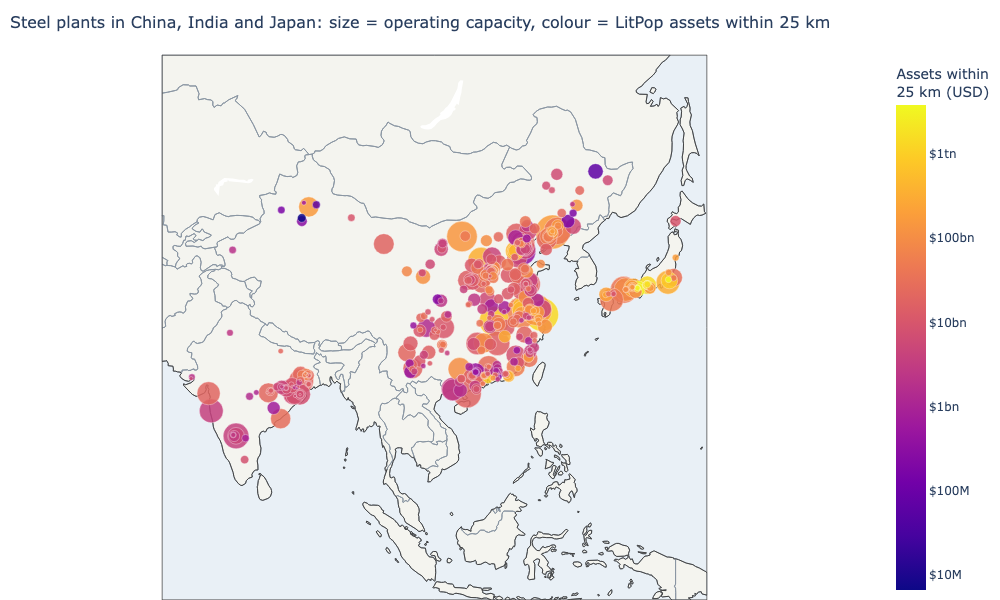

450 operating plants shown (162 matched plants have no operating steel capacity and are left out of this map).


In [23]:
# Create visualization of plants colored by LitPop exposure metrics

covered = plants_litpop[plants_litpop["litpop_matched"]].copy()
covered["exposure_25km_bn"] = covered["litpop_value_25km_usd"] / 1e9
covered["exposure_cell_m"] = covered["litpop_value_nearest_usd"] / 1e6
covered["log10_exposure"] = np.log10(covered["litpop_value_25km_usd"].clip(lower=1))
covered_operating = covered[covered["capacity_operating_ttpa"] > 0].sort_values(
    "capacity_operating_ttpa", ascending=False
)

fig_exposure = px.scatter_geo(
    covered_operating,
    lat="Latitude",
    lon="Longitude",
    color="log10_exposure",
    size="capacity_operating_ttpa",
    size_max=24,
    color_continuous_scale="Plasma",
    hover_name="Plant name (English)",
    hover_data={
        "Owner": True,
        "Country/Area": True,
        "capacity_operating_ttpa": ":,.0f",
        "exposure_25km_bn": ":,.1f",
        "exposure_cell_m": ":,.0f",
        "litpop_distance_km": ":.1f",
        "log10_exposure": False,
        "Latitude": False,
        "Longitude": False,
    },
    labels={
        **HOVER_LABELS,
        "exposure_25km_bn": "Assets within 25 km (USD bn)",
        "exposure_cell_m": "Nearest cell value (USD M)",
        "litpop_distance_km": "Distance to cell centre (km)",
    },
    opacity=0.85,
)
fig_exposure.update_traces(marker=dict(line=dict(width=0.4, color="white")))
fig_exposure.update_geos(
    fitbounds="locations",
    projection_type="mercator",
    showcountries=True,
    countrycolor="#8a96a3",
    showland=True,
    landcolor="#f4f4ef",
    showocean=True,
    oceancolor="#e9f0f6",
    showsubunits=True,
    subunitcolor="#d5dbe1",
)
exposure_ticks = [
    v
    for v in USD_TICKS
    if covered_operating["log10_exposure"].min() - 1 < v < covered_operating["log10_exposure"].max() + 1
]
fig_exposure.update_layout(
    title=dict(
        text="Steel plants in China, India and Japan: size = operating capacity, colour = LitPop assets within 25 km",
        x=0.01,
        font=dict(size=16),
    ),
    height=600,
    margin=dict(l=0, r=0, t=55, b=0),
    coloraxis_colorbar=dict(
        title=dict(text="Assets within<br>25 km (USD)"),
        tickvals=exposure_ticks,
        ticktext=[USD_TICKS[v] for v in exposure_ticks],
    ),
)
fig_exposure.show()
print(
    f"{len(covered_operating):,} operating plants shown ({len(covered) - len(covered_operating)} matched plants have no operating steel capacity and are left out of this map)."
)

Spearman correlation between plant capacity and LitPop assets within 25 km:


,Spearman rho
All three countries,0.12
China,0.16
India,0.06
Japan,-0.12


Plants grouped by local exposure quartile (within country):


,plants,capacity_mtpa,median_capacity_ttpa,median_assets_25km_bn,share of capacity %
exposure_quartile,,,,,
Q1 lowest,113,280.90,"1,350.00",2.60,21.00
Q2,112,313.10,"2,020.50",10.20,23.40
Q3,112,326.80,"1,895.00",24.40,24.50
Q4 highest,113,415.40,"2,300.00",108.10,31.10


Percentile of the plant's own grid cell within its country's LitPop cells (50 = a typical cell):


,count,mean,std,min,25%,50%,75%,max
Country/Area,,,,,,,,
China,348.00,94.90,6.60,37.70,94.00,96.60,98.50,99.90
India,64.00,92.40,7.80,62.40,90.50,95.20,98.00,99.80
Japan,38.00,95.10,3.60,84.80,93.80,94.90,97.80,99.80


,plants,capacity_mtpa,median_assets_25km_bn,max_assets_25km_bn
Country/Area,,,,
China,348,"1,084.80",17.20,"1,390.80"
India,64,145.50,7.60,61.80
Japan,38,105.90,154.70,"3,813.00"


Large plants (>= 5,000 ttpa) with the highest asset value within 25 km:


,Plant name (English),Owner,Country/Area,capacity_operating_ttpa,exposure_25km_bn,cell_percentile
780,Nippon Nagoya steel plant,Nippon Steel Corp,Japan,"6,000.00","1,460.90",94.60
131,Baoshan Iron and Steel Co Ltd Headquarters,Baoshan Iron & Steel Co Ltd,China,"19,800.00","1,390.80",99.90
1213,Wuhan Iron and Steel Co Ltd,Wuhan Iron and Steel Co Ltd,China,"15,907.00",792.60,99.50
759,Nanjing Iron and Steel Co Ltd,Nanjing Iron & Steel Co Ltd,China,"10,000.00",555.30,99.50
962,Shanghai Meishan Iron and Steel Co Ltd,Shanghai Meishan Iron & Steel Co Ltd,China,"7,600.00",433.60,98.50
1115,Tianjin Iron and Steel Group Co Ltd,Tianjin Iron and Steel Group Co Ltd,China,"6,650.00",420.20,99.20
974,Shanxi Taigang Stainless Steel Co Ltd,Shanxi Taigang Stainless Steel Co Ltd,China,"12,460.00",350.70,99.80
775,Nippon East Japan Works (Kimitsu) steel plant,Nippon Steel Corp,Japan,"10,001.00",326.60,94.30
644,Kobe Kakogawa Works steel plant,Kobe Steel Ltd,Japan,"6,591.00",254.70,97.10
44,Angang Steel Co Ltd,Angang Steel Co Ltd,China,"20,650.00",177.20,99.90


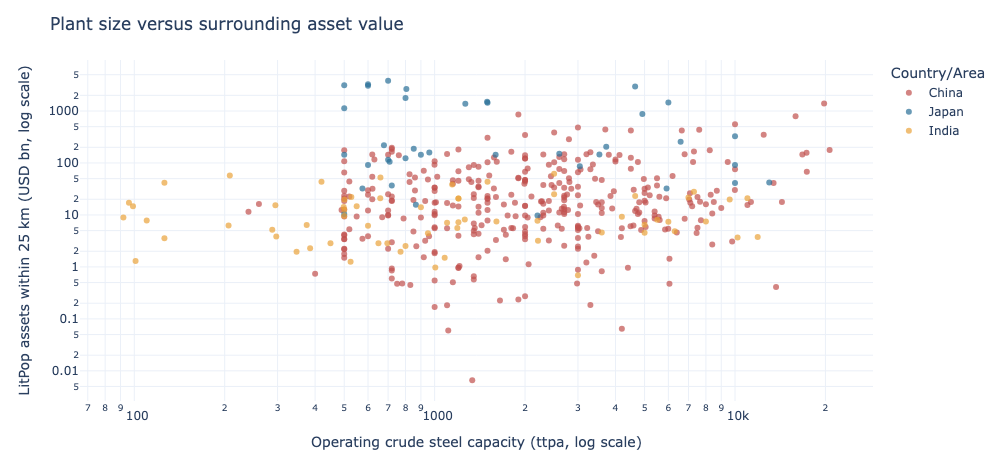

In [24]:
# Evidence for the interpretation: where do LARGE plants sit relative to high asset-value areas?
def rank_correlation(x: pd.Series, y: pd.Series) -> float:
    """Spearman correlation (Pearson correlation of the ranks): robust to the heavy skew of both variables."""
    return float(x.rank().corr(y.rank()))


print("Spearman correlation between plant capacity and LitPop assets within 25 km:")
correlations = {
    "All three countries": rank_correlation(
        covered_operating["capacity_operating_ttpa"], covered_operating["litpop_value_25km_usd"]
    )
}
for country, group in covered_operating.groupby("Country/Area"):
    correlations[country] = rank_correlation(group["capacity_operating_ttpa"], group["litpop_value_25km_usd"])
display(pd.Series(correlations, name="Spearman rho").round(3).to_frame())

# Exposure quartiles (computed within each country so that Japan's much higher asset values do not dominate)
covered_operating = covered_operating.assign(
    exposure_quartile=covered_operating.groupby("Country/Area")["litpop_value_25km_usd"].transform(
        lambda v: pd.qcut(v.rank(method="first"), 4, labels=["Q1 lowest", "Q2", "Q3", "Q4 highest"])
    )
)
quartile_table = covered_operating.groupby("exposure_quartile", observed=True).agg(
    plants=("Plant ID", "size"),
    capacity_mtpa=("capacity_operating_ttpa", lambda s: s.sum() / 1000),
    median_capacity_ttpa=("capacity_operating_ttpa", "median"),
    median_assets_25km_bn=("exposure_25km_bn", "median"),
)
quartile_table["share of capacity %"] = (
    quartile_table["capacity_mtpa"] / quartile_table["capacity_mtpa"].sum() * 100
).round(1)
print("Plants grouped by local exposure quartile (within country):")
display(quartile_table.round(1))

# How unusual is a steel plant's location? Percentile of its own cell within the national distribution of cells
sorted_values = {iso3: np.sort(group["value"].to_numpy()) for iso3, group in litpop.groupby("iso3")}
covered_operating["cell_percentile"] = [
    np.searchsorted(sorted_values[iso3], value, side="right") / len(sorted_values[iso3]) * 100
    for iso3, value in zip(covered_operating["litpop_iso3"], covered_operating["litpop_value_nearest_usd"])
]
print("Percentile of the plant's own grid cell within its country's LitPop cells (50 = a typical cell):")
display(covered_operating.groupby("Country/Area")["cell_percentile"].describe(percentiles=[0.25, 0.5, 0.75]).round(1))

country_view = covered_operating.groupby("Country/Area").agg(
    plants=("Plant ID", "size"),
    capacity_mtpa=("capacity_operating_ttpa", lambda s: s.sum() / 1000),
    median_assets_25km_bn=("exposure_25km_bn", "median"),
    max_assets_25km_bn=("exposure_25km_bn", "max"),
)
display(country_view.round(1))

LARGE_PLANT_TTPA = 5000
print(f"Large plants (>= {LARGE_PLANT_TTPA:,} ttpa) with the highest asset value within 25 km:")
display(
    covered_operating[covered_operating["capacity_operating_ttpa"] >= LARGE_PLANT_TTPA]
    .nlargest(10, "litpop_value_25km_usd")[
        [
            "Plant name (English)",
            "Owner",
            "Country/Area",
            "capacity_operating_ttpa",
            "exposure_25km_bn",
            "cell_percentile",
        ]
    ]
    .round(1)
)

fig_scatter = px.scatter(
    covered_operating,
    x="capacity_operating_ttpa",
    y="exposure_25km_bn",
    color="Country/Area",
    log_x=True,
    log_y=True,
    hover_name="Plant name (English)",
    opacity=0.7,
    height=460,
    labels={
        "capacity_operating_ttpa": "Operating crude steel capacity (ttpa, log scale)",
        "exposure_25km_bn": "LitPop assets within 25 km (USD bn, log scale)",
    },
    title="Plant size versus surrounding asset value",
    color_discrete_map={"China": "#c0504d", "India": "#e9a23b", "Japan": "#2a6f97"},
)
fig_scatter.update_layout(margin=dict(t=60, b=40))
fig_scatter.show()

#### Interpretation: where do large plants sit relative to high asset-value areas?

1. **Plants tend to occupy asset-rich cells.** The median matched cell is at the 96.6th percentile of national cell values in China, 95.2nd in India and 94.9th in Japan.
2. **Plant size has only a weak relationship with surrounding assets.** Spearman rank correlation is 0.12 overall (China 0.16, India 0.06, Japan −0.12). Within-country exposure quartiles show 31% of operating capacity in the highest quartile versus 21% in the lowest.
3. **Location matters.** Median assets within 25 km are about USD 155 bn in Japan, 17 bn in China and 8 bn in India. Large metropolitan sites include Nagoya (about USD 1,460 bn) and Baosteel in Shanghai (1,390 bn). Large plants such as Hazira (20 bn) and Angul (7 bn) have much lower surrounding asset values.

**Limits.** LitPop measures surrounding produced capital, not the plant's value, population or expected damage. Hazard and vulnerability data would be needed to estimate climate risk. The grid is coarse (about 9 km), its reference year is 2018, and 152 plant locations are approximate. Night lights from a plant may also influence its own cell's allocated value. Overlapping 25 km circles must not be summed as distinct assets.

---
## Part 5: Company-Level Aggregation

Aggregate data at the company level to analyze corporate footprints: including capacity and the LitPop exposure context you attached in Part 4.


### Exercise 1: Aggregate Metrics by Company
**Task:** Group plants by company (`Owner`) and calculate aggregate metrics.
- Total capacity per company
- Number of plants per company
- Average LitPop exposure metrics per company (from Part 4)
- Geographic spread (e.g. number of `Country/Area` or `Region` values)


In [25]:
# Group by company and aggregate


def summarise_companies(plants: pd.DataFrame, by: str = "Owner") -> pd.DataFrame:
    """One row per company: size, footprint and average LitPop exposure of its plants."""
    plants = plants[
        plants[by].astype(str).str.strip().str.lower() != "unknown"
    ]  # "unknown" is a placeholder, not a company
    summary = plants.groupby(by).agg(
        n_plants=("Plant ID", "nunique"),
        n_operating_plants=("capacity_operating_ttpa", lambda s: int((s > 0).sum())),
        total_capacity_ttpa=("capacity_operating_ttpa", lambda s: s.sum(min_count=1)),
        pipeline_capacity_ttpa=("capacity_pipeline_ttpa", lambda s: s.sum(min_count=1)),
        n_countries=("Country/Area", "nunique"),
        n_regions=("Region", "nunique"),
        countries=("Country/Area", lambda s: ", ".join(sorted(set(s)))),
        main_region=("Region", lambda s: s.value_counts().index[0]),
        median_plant_age_years=("Plant age (years)", "median"),
        n_plants_with_litpop=("litpop_matched", "sum"),
        avg_litpop_nearest_usd=("litpop_value_nearest_usd", "mean"),
        avg_litpop_25km_usd=("litpop_value_25km_usd", "mean"),
    )
    # Capacity-weighted exposure: a company's big plants count more than its small ones
    weights = plants["capacity_operating_ttpa"].where(plants["litpop_value_25km_usd"].notna())
    weighted_sum = (plants["litpop_value_25km_usd"] * weights).groupby(plants[by]).sum(min_count=1)
    summary["capacity_weighted_litpop_25km_usd"] = weighted_sum / weights.groupby(plants[by]).sum(min_count=1)
    summary["litpop_coverage_share"] = summary["n_plants_with_litpop"] / summary["n_plants"]
    if "capacity_operating_bof_ttpa" in plants.columns:  # share of operating capacity on the coal-based BOF route
        summary["bof_share"] = plants.groupby(by)["capacity_operating_bof_ttpa"].sum() / summary[
            "total_capacity_ttpa"
        ].where(summary["total_capacity_ttpa"] > 0)
    return summary.sort_values("total_capacity_ttpa", ascending=False)


company_summary = summarise_companies(plants_litpop, by="Owner")
print(
    f"Plants left out because their owner is 'unknown': {int((plants_litpop['Owner'].str.lower() == 'unknown').sum())}"
)
print(
    f"{len(company_summary):,} companies (immediate owners); {int((company_summary['n_plants_with_litpop'] > 0).sum()):,} have at least one plant with LitPop exposure."
)
display(
    company_summary.head(15)
    .assign(
        capacity_mtpa=lambda t: t["total_capacity_ttpa"] / 1000,
        avg_assets_25km_bn=lambda t: t["avg_litpop_25km_usd"] / 1e9,
        weighted_assets_25km_bn=lambda t: t["capacity_weighted_litpop_25km_usd"] / 1e9,
        bof_share_pct=lambda t: t.get("bof_share", pd.Series(np.nan, index=t.index)) * 100,
    )[
        [
            "n_plants",
            "n_operating_plants",
            "capacity_mtpa",
            "bof_share_pct",
            "n_countries",
            "n_regions",
            "median_plant_age_years",
            "n_plants_with_litpop",
            "avg_assets_25km_bn",
            "weighted_assets_25km_bn",
        ]
    ]
    .round(1)
)
print("Geographic spread: companies by number of countries/areas in which they own plants")
display(company_summary["n_countries"].value_counts().sort_index().rename_axis("countries/areas").to_frame("companies"))
print("Most multinational owners:")
display(
    company_summary.sort_values(["n_countries", "total_capacity_ttpa"], ascending=False).head(5)[
        ["n_plants", "n_countries", "countries"]
    ]
)

Plants left out because their owner is 'unknown': 2
1,068 companies (immediate owners); 534 have at least one plant with LitPop exposure.


,n_plants,n_operating_plants,capacity_mtpa,bof_share_pct,n_countries,n_regions,median_plant_age_years,n_plants_with_litpop,avg_assets_25km_bn,weighted_assets_25km_bn
Owner,,,,,,,,,,
Nippon Steel Corp,10,8,44.40,96.20,1,1,70.90,10,257.50,319.50
POSCO Holdings Inc,2,2,41.80,96.80,1,1,46.00,0,NaN,NaN
Angang Steel Co Ltd,3,3,30.20,100.00,1,1,20.00,3,74.00,128.10
JFE Steel Corp,5,4,28.80,95.60,1,1,61.00,5,890.10,206.90
JSW Steel Ltd,5,4,28.40,58.70,1,1,30.00,5,4.50,4.40
Tata Steel Ltd,6,5,26.50,83.10,2,1,55.00,5,15.90,14.00
Hyundai Steel Co,4,3,24.30,51.90,2,2,46.50,0,NaN,NaN
Cleveland-Cliffs Inc,12,8,23.70,90.50,2,1,111.00,0,NaN,NaN
Steel Authority of India Ltd,8,6,21.40,97.70,1,1,67.00,8,23.40,24.60


Geographic spread: companies by number of countries/areas in which they own plants


,companies
countries/areas,
1,1050
2,16
4,1
5,1


Most multinational owners:


,n_plants,n_countries,countries
Owner,,,
ArcelorMittal SA,6,5,"Belgium, India, Luxembourg, Morocco, United States"
Liberty Steel Group,6,4,"France, Hungary, United Kingdom, United States"
Tata Steel Ltd,6,2,"India, Singapore"
Hyundai Steel Co,4,2,"South Korea, United States"
Cleveland-Cliffs Inc,12,2,"Canada, United States"


**Reading the company table.** Metrics per company (immediate `Owner`): number of plants, operating and pipeline capacity, geographic spread (countries and regions), median plant age, share of capacity on the coal-based BOF route, and LitPop exposure averaged over the company's matched plants, both as a simple mean and weighted by capacity. Exposure is only defined for the 534 companies with at least one plant in China, India or Japan: for the others it stays missing instead of being filled with zeros.

Spread is low at this level: 1,050 of 1,068 owners operate in a single country. `ArcelorMittal SA` (5 countries) is the exception, illustrating the difference between immediate owners and consolidated groups. Parent stakes are incomplete or inconsistent for some plants, so no equity-weighted parent ranking is inferred.

**Technology.** 65.5% of world operating capacity uses the coal-based BOF route and 32.3% the EAF route. Among the largest owners the BOF share is 96% for Nippon Steel and JFE, 98% for SAIL and 100% for Angang, against 59% for JSW and 0% for Nucor: similar capacities can have different technology mixes. Transition risk also depends on energy sources, policy and retrofit options.

### Exercise 2: Company Headquarters or Centroid
**Task:** Calculate a representative location for each company.
- Option 1: Use the centroid of all plant locations
- Option 2: Use the location of the largest plant
- Option 3: Assign actual headquarters coordinates


In [26]:
# Calculate company representative locations


def weighted_spherical_centroid(lat_deg: ArrayLike, lon_deg: ArrayLike, weights: ArrayLike) -> tuple[float, float]:
    """Centre of gravity on the sphere: average the 3-D unit vectors, then convert back to latitude/longitude.

    Averaging raw latitudes and longitudes would break around the antimeridian and distort long distances.
    Falls back to equal weights when no weight is positive (for example a company with only announced plants).
    """
    lat, lon = np.deg2rad(np.asarray(lat_deg, dtype=float)), np.deg2rad(np.asarray(lon_deg, dtype=float))
    w = np.nan_to_num(np.asarray(weights, dtype=float), nan=0.0)
    if w.sum() <= 0:
        w = np.ones_like(lat)
    x, y, z = (np.average(v, weights=w) for v in (np.cos(lat) * np.cos(lon), np.cos(lat) * np.sin(lon), np.sin(lat)))
    return float(np.rad2deg(np.arctan2(z, np.hypot(x, y)))), float(np.rad2deg(np.arctan2(y, x)))


def locate_companies(plants: pd.DataFrame, by: str = "Owner") -> pd.DataFrame:
    """Two representative locations per company: capacity-weighted centroid (option 1) and largest plant (option 2)."""
    records = []
    for company, group in plants.groupby(by):
        centroid_lat, centroid_lon = weighted_spherical_centroid(
            group["Latitude"], group["Longitude"], group["capacity_operating_ttpa"]
        )
        largest = group.sort_values("capacity_operating_ttpa", ascending=False, kind="stable").iloc[0]
        distances = haversine_km(centroid_lat, centroid_lon, group["Latitude"], group["Longitude"])
        records.append(
            {
                by: company,
                "centroid_lat": centroid_lat,
                "centroid_lon": centroid_lon,
                "largest_plant": largest["Plant name (English)"],
                "largest_plant_lat": largest["Latitude"],
                "largest_plant_lon": largest["Longitude"],
                "max_distance_to_centroid_km": float(distances.max()),
                "centroid_to_largest_plant_km": float(
                    haversine_km(centroid_lat, centroid_lon, largest["Latitude"], largest["Longitude"])
                ),
            }
        )
    return pd.DataFrame(records).set_index(by)


company_locations = locate_companies(plants_litpop, by="Owner")
companies = company_summary.join(company_locations)
assert companies[["centroid_lat", "centroid_lon"]].notna().all().all()

single_site = int((companies["n_plants"] == 1).sum())
print(
    f"{single_site:,} of {len(companies):,} companies own a single plant: centroid and largest-plant location coincide for them."
)
print("Multi-plant companies whose centroid lies farthest from their largest plant:")
display(
    companies[companies["n_plants"] > 1]
    .nlargest(8, "centroid_to_largest_plant_km")[
        [
            "n_plants",
            "n_countries",
            "centroid_lat",
            "centroid_lon",
            "largest_plant",
            "centroid_to_largest_plant_km",
            "max_distance_to_centroid_km",
        ]
    ]
    .round(1)
)

962 of 1,068 companies own a single plant: centroid and largest-plant location coincide for them.
Multi-plant companies whose centroid lies farthest from their largest plant:


,n_plants,n_countries,centroid_lat,centroid_lon,largest_plant,centroid_to_largest_plant_km,max_distance_to_centroid_km
Owner,,,,,,,
Meranti Steel Pte Ltd,2,2,17.30,79.80,Meranti Green Steel Duqm DRI plant,"2,347.30","2,347.30"
Stegra AB,2,2,53.80,5.10,Stegra Boden steel plant,"1,620.50","1,620.50"
ArcelorMittal Brasil SA,6,1,-15.10,-42.40,ArcelorMittal Pecém steel plant,"1,334.20","1,334.20"
GravitHy,2,2,53.10,11.30,GravitHy Fos sur Mer iron plant,"1,177.30","1,177.30"
Gerdau Ameristeel Corp,8,2,37.40,-87.00,Gerdau Midlothian Steel Mill,"1,069.30","1,069.30"
Commercial Metals Co,8,1,34.20,-90.00,CMC Steel Texas plant,911.90,"1,991.70"
Tosyalı Holding AŞ,2,2,32.40,43.00,Tosyali Ras Al Khair steel plant,809.10,809.10
Nucor Corp,13,1,37.20,-86.70,Nucor Steel Berkeley plant,776.40,"3,114.00"


**Which representative location?** Both options are computed. Option 1 is a capacity-weighted centroid, calculated on the sphere (averaging 3-D unit vectors) because averaging raw longitudes breaks for companies spread across the globe. Option 2 is the location of the company's largest plant.

**We map option 2.** For the 90% of companies with a single plant the two coincide. For multi-plant companies the centroid can fall where the company owns nothing: ArcelorMittal Brasil's centroid is 1,300 km from its largest plant, and Commercial Metals' farthest plant is about 2,000 km from its centroid. A marker at the largest plant always sits on a real asset, which also keeps the LitPop colour meaningful. Option 3 (headquarters) would need an external, manually collected dataset for more than 1,000 companies.

### Exercise 3: Visualize Company-Level Data
**Task:** Create a map showing companies with aggregated metrics.
- Show one marker per company at the representative location
- Size by total capacity
- Color by average LitPop exposure (or another Part 4 metric)
- Hover information with company summary statistics


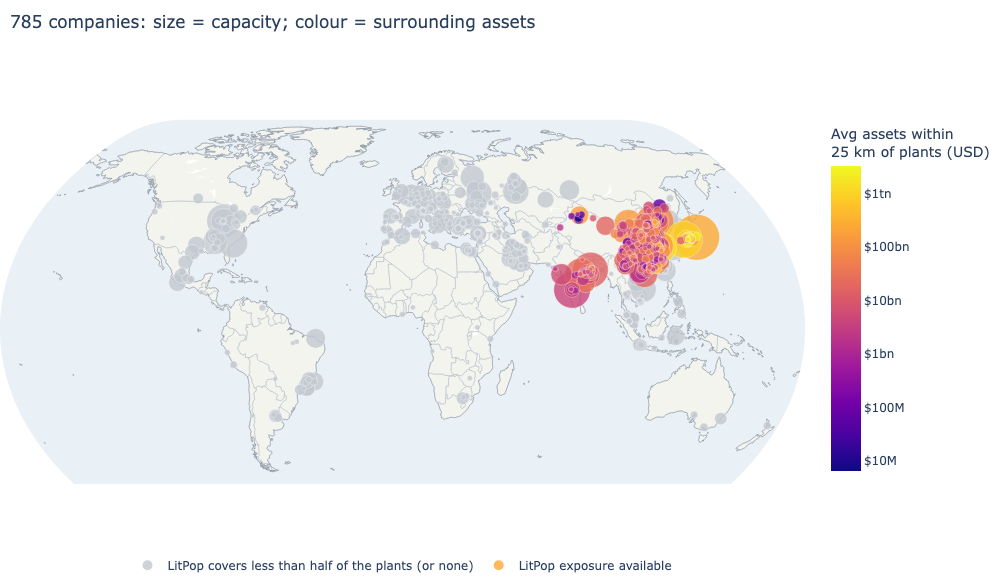

408 companies coloured by exposure; 377 in grey, of which 1 have some plants in the sample but less than 50% of them: ArcelorMittal SA.


In [27]:
# Create company-level visualization

REPRESENTATIVE_LOCATION = ("largest_plant_lat", "largest_plant_lon")  # see the note above for why option 2 is mapped
MAX_MARKER_PX = 46

map_companies = companies[companies["total_capacity_ttpa"] > 0].copy()
map_companies["capacity_mtpa"] = map_companies["total_capacity_ttpa"] / 1000
map_companies["avg_assets_25km_bn"] = map_companies["avg_litpop_25km_usd"] / 1e9
map_companies["log10_exposure"] = np.log10(map_companies["avg_litpop_25km_usd"].clip(lower=1))
lat_col, lon_col = REPRESENTATIVE_LOCATION
size_ref = 2.0 * map_companies["capacity_mtpa"].max() / MAX_MARKER_PX**2  # marker AREA proportional to capacity


def company_trace(data: pd.DataFrame, name: str, **marker: object) -> go.Scattergeo:
    """One Scattergeo trace with a shared hover box."""
    exposure_label = data["avg_assets_25km_bn"].map(
        lambda value: "Unavailable" if pd.isna(value) else f"{value:,.1f} USD bn"
    )
    custom = np.stack(
        [
            data["n_plants"],
            data["capacity_mtpa"],
            data["n_countries"],
            exposure_label,
            data["n_plants_with_litpop"],
            data["largest_plant"],
            data["countries"].str.slice(0, 60),
        ],
        axis=-1,
    )
    return go.Scattergeo(
        lat=data[lat_col],
        lon=data[lon_col],
        text=data.index,
        customdata=custom,
        name=name,
        mode="markers",
        marker=dict(
            size=data["capacity_mtpa"],
            sizemode="area",
            sizeref=size_ref,
            sizemin=2.5,
            opacity=0.8,
            line=dict(width=0.4, color="white"),
            **marker,
        ),
        hovertemplate="<b>%{text}</b><br>Plants: %{customdata[0]} in %{customdata[2]} countries/areas (%{customdata[6]})"
        "<br>Operating capacity: %{customdata[1]:,.1f} Mtpa<br>Largest plant: %{customdata[5]}"
        "<br>Avg LitPop assets within 25 km: %{customdata[3]} (%{customdata[4]} plants covered)<extra></extra>",
    )


MIN_LITPOP_COVERAGE = 0.5  # an average based on a minority of a company's plants would not represent the company
has_exposure = map_companies["avg_litpop_25km_usd"].notna() & (
    map_companies["litpop_coverage_share"] >= MIN_LITPOP_COVERAGE
)
with_exposure = map_companies[has_exposure].sort_values("capacity_mtpa", ascending=False)
without_exposure = map_companies[~has_exposure].sort_values("capacity_mtpa", ascending=False)
company_ticks = [
    v for v in USD_TICKS if with_exposure["log10_exposure"].min() - 1 < v < with_exposure["log10_exposure"].max() + 1
]

fig_companies = go.Figure(
    [
        company_trace(without_exposure, "LitPop covers less than half of the plants (or none)", color="#c3c9d1"),
        company_trace(
            with_exposure,
            "LitPop exposure available",
            color=with_exposure["log10_exposure"],
            colorscale="Plasma",
            colorbar=dict(
                title=dict(text="Avg assets within<br>25 km of plants (USD)"),
                tickvals=company_ticks,
                ticktext=[USD_TICKS[v] for v in company_ticks],
                len=0.75,
            ),
        ),
    ]
)
style_world_map(
    fig_companies, f"{len(map_companies):,} companies: size = capacity; colour = surrounding assets", height=580
)
fig_companies.show()
partly_covered = map_companies[map_companies["avg_litpop_25km_usd"].notna() & ~has_exposure]
print(
    f"{len(with_exposure):,} companies coloured by exposure; {len(without_exposure):,} in grey, of which {len(partly_covered)} have some plants in the sample "
    f"but less than {MIN_LITPOP_COVERAGE:.0%} of them: {', '.join(partly_covered.index[:6])}."
)

#### Interpretation of the company map

- The map has one marker per company with operating capacity (785), at its largest plant. 408 companies are coloured by average exposure. Of the 377 grey companies, 376 have no matched exposure and one has coverage below 50%. Grey does not mean low exposure. A company is only coloured when LitPop covers at least half of its plants: `ArcelorMittal SA` has one Indian plant in the sample out of six, and colouring its marker in Belgium with an Indian value would mislead.
- **Japanese groups combine size and the highest exposure**: Nippon Steel, JFE and Kobe Steel operate large coastal works inside metropolitan areas, with average assets within 25 km of their plants of about USD 260 bn (Nippon Steel), 890 bn (JFE) and 840 bn (Kobe Steel).
- **Chinese companies span the whole range**, from Baosteel in Shanghai (about USD 1,390 bn) to inland steel towns below 10 bn. **Indian majors (JSW, Tata, SAIL) show low exposure** (roughly USD 4 to 25 bn) because their plants are in the mineral belt, far from the big cities.
- Most immediate owners have one plant in one country, so their company exposure summary reflects that single plant. This does not establish the diversification or climate risk of the ultimate corporate group.

---
## Part 6: Streamlit Dashboard Integration

Prepare your visualizations for deployment in a Streamlit dashboard.


### Exercise 1: Create Dashboard Script Structure
**Task:** Create a Streamlit app file (`app.py`) with the following structure:

```python
# Import streamlit and other necessary libraries

# Set page configuration

# Title and description

# Sidebar for filters
# - Company selector
# - Region/country filter
# - Capacity range slider

# Main content area
# - KPI metrics (total plants, total capacity, etc.)
# - Interactive map
# - Data table

# Footer with data sources and notes
```


#### `app.py` in this repository

The dashboard follows the structure requested above:

| Section | Implementation in `app.py` |
|---|---|
| Imports and page configuration | `st.set_page_config(layout="wide")`; current Plotly map functions |
| Title and description | Title plus one paragraph stating the data release that is loaded |
| Sidebar filters | **Company** multiselect (sorted by capacity), **region** and **country** multiselects (country options follow the region), **capacity range slider**, plus status, steelmaking route and a LitPop-only switch |
| KPI metrics | Plants, operating capacity, share of world capacity, pipeline, companies, median plant age: all follow the filters |
| Interactive map | Tab 1: plant map (size = capacity, colour by region, route, status or top 10 companies) or density heatmap (optionally weighted by capacity). Tab 2: LitPop exposure map with optional exposure grid. Tab 3: company-level map |
| Data table | Tab 5: filtered table with links to the GEM wiki and a CSV download |
| Footer | Data sources, licence and the method notes needed to read the numbers |

Run it from the repository root with `streamlit run app.py`. It only reads the processed files in `data/`, written by the next cell.

### Exercise 1: Prepare Data for Dashboard
**Task:** Save your processed data to files that the dashboard will load.
- Export cleaned plant data
- Export merged plant + LitPop exposure data
- Export company-level aggregations
- Save as CSV or Parquet for efficient loading


In [28]:
# Save processed datasets


def export_table(table: pd.DataFrame, name: str) -> dict[str, str | int | float | None]:
    """Write `table` as CSV (readable on GitHub) and, when a Parquet engine is installed, as Parquet (typed, fast)."""
    EXPORT_DIR.mkdir(exist_ok=True)
    csv_path = EXPORT_DIR / f"{name}.csv"
    table.to_csv(csv_path, index=False, encoding="utf-8")
    written = {
        "table": name,
        "rows": len(table),
        "columns": table.shape[1],
        "csv_kb": round(csv_path.stat().st_size / 1024, 1),
    }
    try:
        parquet_path = EXPORT_DIR / f"{name}.parquet"
        table.to_parquet(parquet_path, index=False)
        written["parquet_kb"] = round(parquet_path.stat().st_size / 1024, 1)
    except ImportError:  # no pyarrow / fastparquet: the dashboard falls back to the CSV
        written["parquet_kb"] = None
    return written


DISPLAY_ONLY_COLUMNS = ["capacity_label"]  # presentation helpers are rebuilt by the dashboard
plants_clean_export = steel_plants.drop(columns=DISPLAY_ONLY_COLUMNS, errors="ignore")
plants_litpop_export = plants_litpop.drop(columns=DISPLAY_ONLY_COLUMNS, errors="ignore")
companies_export = companies.reset_index()

export_log = [
    export_table(plants_clean_export, "plants_clean"),  # cleaned plant data
    export_table(plants_litpop_export, "plants_litpop"),  # plants + LitPop exposure
    export_table(companies_export, "companies"),  # company-level aggregation
    export_table(litpop_grid.round(4), "litpop_grid"),  # 0.5-degree exposure layer for the dashboard background
]
metadata = {
    "gem_release": GEM_RELEASE,
    "gem_file": gem_path.name,
    "litpop_files": {iso3: text for iso3, text in litpop_descriptions.items()},
    "capacity_metric": "operating + operating pre-retirement nominal crude steel capacity (ttpa)",
    "max_match_distance_km": MAX_MATCH_DISTANCE_KM,
    "neighbourhood_radius_km": NEIGHBOURHOOD_RADIUS_KM,
    "litpop_preview_grid_deg": PREVIEW_DEG,
}
(EXPORT_DIR / "metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")
display(pd.DataFrame(export_log).set_index("table"))
print("Saved to", EXPORT_DIR.as_posix() + "/:", sorted(p.name for p in EXPORT_DIR.iterdir()))

,rows,columns,csv_kb,parquet_kb
table,,,,
plants_clean,1293,32,517.10,225.70
plants_litpop,1293,40,591.60,257.50
companies,1068,23,231.80,126.10
litpop_grid,5353,5,177.80,74.00


Saved to data/: ['LitPop_pc_300_arcsec_CHN_v1.hdf5', 'LitPop_pc_300_arcsec_IND_v1.hdf5', 'LitPop_pc_300_arcsec_JPN_v1.hdf5', 'companies.csv', 'companies.parquet', 'litpop_grid.csv', 'litpop_grid.parquet', 'metadata.json', 'plants_clean.csv', 'plants_clean.parquet', 'plants_litpop.csv', 'plants_litpop.parquet']


### Exercise 2: Display relevant information from your exploratory analysis into the dashboard

**From the exploratory analysis to the dashboard.** The *Insights* tab rebuilds the main charts of Part 2 on the current selection: operating capacity against pipeline by country (Question 4), capacity by status bucket (the 3,672 against 2,229 Mtpa point), top owners, the steelmaking route mix and the plant-age histogram by region (Question 2). The *Exposure* tab carries the Part 4 map and the size-against-exposure scatter, and the *Companies* tab the Part 5 aggregation, recomputed for the filtered plants. The cell below runs the app headlessly with Streamlit's testing API to prove that it starts without errors on the exported files.

In [29]:
# Automated check that the dashboard runs end to end on the files exported above (headless, no browser needed).
try:
    from streamlit.testing.v1 import AppTest
except ImportError:
    print(
        "streamlit is not installed in this environment: run `pip install -r requirements.txt`, then `streamlit run app.py`."
    )
else:
    import logging

    for logger_name in list(
        logging.root.manager.loggerDict
    ):  # Streamlit warns about running outside `streamlit run`: expected here
        if logger_name.startswith("streamlit"):
            logging.getLogger(logger_name).setLevel(logging.ERROR)
    app_test = AppTest.from_file(
        str(Path("app.py").resolve()), default_timeout=120
    ).run()  # absolute path: AppTest resolves relative ones against its caller
    print("Uncaught exceptions :", len(app_test.exception))
    print("KPI cards           :", [(metric.label, metric.value) for metric in app_test.metric])
    print(
        "Sidebar filters     :",
        [widget.label for widget in list(app_test.sidebar.multiselect) + list(app_test.sidebar.slider)],
    )
    print("Tabs                :", [tab.label for tab in app_test.tabs])
    assert not app_test.exception, "the dashboard raised an exception"

Uncaught exceptions : 0
KPI cards           : [('Plants', '1,293'), ('Operating capacity (Mtpa)', '2,229'), ('Share of world capacity', '100.0%'), ('Pipeline (Mtpa)', '831'), ('Companies', '1,068'), ('Median plant age (years)', '25'), ('Plants with exposure', '612'), ('Median assets within 25 km', '$17.5 bn'), ('Capacity covered (Mtpa)', '1,336')]
Sidebar filters     : ['Region', 'Country / area', 'Company (owner)', 'Plant status', 'Steelmaking route', 'Operating capacity (thousand tonnes per year)']
Tabs                : ['🗺️ Plant map', '🏙️ Exposure (LitPop)', '🏢 Companies', '📊 Insights', '📋 Data']


In [30]:
# Measurements behind the notes below: load time of the exports and weight of one map sent to the browser
timings = {}
for name in ("plants_litpop", "companies"):
    for suffix, reader in ((".csv", pd.read_csv), (".parquet", pd.read_parquet)):
        path = EXPORT_DIR / f"{name}{suffix}"
        if path.exists():
            reader(path)  # warm-up: the first call also pays for importing the file reader
            runs = []
            for _ in range(5):
                start = time.perf_counter()
                reader(path)
                runs.append((time.perf_counter() - start) * 1000)
            timings[f"{name}{suffix}"] = {
                "size_kb": round(path.stat().st_size / 1024, 1),
                "best_load_ms": round(min(runs), 1),
            }
display(pd.DataFrame(timings).T)
print(f"Plant map payload      : {len(fig_sized.to_json()) / 1024:,.0f} KB for {len(sized_plants):,} plants")
print(
    f"Full LitPop sample     : {len(litpop):,} cells, about {litpop.memory_usage(deep=True).sum() / 1e6:,.0f} MB in memory"
)
print(f"Dashboard exposure grid: {len(litpop_grid):,} blocks of {PREVIEW_DEG} degrees")

,size_kb,best_load_ms
plants_litpop.csv,591.60,6.00
plants_litpop.parquet,257.50,1.60
companies.csv,231.80,1.90
companies.parquet,126.10,0.90


Plant map payload      : 167 KB for 918 plants
Full LitPop sample     : 182,591 cells, about 9 MB in memory
Dashboard exposure grid: 5,353 blocks of 0.5 degrees


#### Notes and observations about the dashboard

**What works well.** The same filters drive the KPIs, maps, charts and table. Company search and capacity ordering help navigate more than 1,000 owners. Excel parsing and spatial matching happen in the notebook; the dashboard caches the small processed exports.

**What could be improved.** Full-country LitPop coverage and hazard layers would support a broader risk assessment. Validated parent ownership would enable consolidated company comparisons. These require additional data, not extra dashboard controls alone.

**Performance.** The plant table has 1,293 rows (about 0.6 MB CSV or 0.26 MB Parquet); the cell above measures file-loading times. The optional exposure background uses 5,353 aggregated blocks instead of sending all 182,591 cells to the browser. The operating-plant map is about 170 KB of JSON. For much larger datasets, map tiles or clustering would reduce the browser workload.

---
## Deployed dashboard (bonus)

The dashboard is hosted on Streamlit Community Cloud: [Open the app](https://aidams-lab1-zeraiki-oumhand-karam-szefner.streamlit.app/).

Deployment uses `app.py` from the repository's `main` branch with Python 3.13.


---
## Our main findings

1. **Capacity depends on status.** The tracker reports 3,672 Mtpa across all statuses, of which **2,229 Mtpa is operating**. Planned, idle and closed capacity must be kept separate.
2. **Geographic concentration.** China holds 35% of plants and **49% of operating capacity**; Hebei alone holds about 10%. India's pipeline is **2.4 times** its operating capacity, versus 0.1 times for China.
3. **Ownership is fragmented at the immediate-owner level.** There are **1,068 known owners**; 90% own one plant and the top ten hold 13% of operating capacity. These are not consolidated corporate groups.
4. **Age and exposure need careful interpretation.** Half of plants with known ages are 25 years old or younger. LitPop matches 612 plants covering 60% of operating capacity, but capacity and surrounding asset value have only a weak rank correlation (0.12). Neither site age nor asset exposure alone establishes climate risk.
5. **The dashboard makes the analysis inspectable.** Company, geography, status, route and capacity filters update the maps, KPIs, charts and downloadable table together.